## Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency
import mlflow
import mlflow.sklearn 
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, roc_curve, precision_recall_curve, classification_report, confusion_matrix)
from sklearn.model_selection import cross_val_score
import shap
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.inspection import permutation_importance

c:\Users\Lenovo\anaconda3\envs\mlops\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Vision globale des données Train et Test

#### Chargement des données brutes

In [2]:
app_test = pd.read_csv("./Données_Brutes/application_test.csv", sep=',')
app_train = pd.read_csv("./Données_Brutes/application_train.csv", sep=',')


#### Découverte des données train et test

In [3]:
# Vue globale des données
pd.set_option("display.max_info_columns", 200)
jeu_donnee = [app_train, app_test]
noms = ["Train", "Test"]
for nom, df in zip(noms, jeu_donnee):
    print(f"\n--- Résumé {nom} ---")
    display(df.head())



--- Résumé Train ---


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0



--- Résumé Test ---


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Dimensions des données
for nom, df in zip(noms, jeu_donnee):
    print(f"\n--- Résumé {nom} ---")
    display(df.shape)


--- Résumé Train ---


(307511, 122)


--- Résumé Test ---


(48744, 121)

In [5]:
# Résumé types de données
pd.set_option("display.max_info_columns", 200)
for nom, df in zip(noms, jeu_donnee):
    print(f"\n--- Informations sur {nom} ---")
    display(df.info())
    


--- Informations sur Train ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 1

None


--- Informations sur Test ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 121 columns):
 #    Column                        Non-Null Count  Dtype  
---   ------                        --------------  -----  
 0    SK_ID_CURR                    48744 non-null  int64  
 1    NAME_CONTRACT_TYPE            48744 non-null  object 
 2    CODE_GENDER                   48744 non-null  object 
 3    FLAG_OWN_CAR                  48744 non-null  object 
 4    FLAG_OWN_REALTY               48744 non-null  object 
 5    CNT_CHILDREN                  48744 non-null  int64  
 6    AMT_INCOME_TOTAL              48744 non-null  float64
 7    AMT_CREDIT                    48744 non-null  float64
 8    AMT_ANNUITY                   48720 non-null  float64
 9    AMT_GOODS_PRICE               48744 non-null  float64
 10   NAME_TYPE_SUITE               47833 non-null  object 
 11   NAME_INCOME_TYPE              48744 non-null  object 
 12   NAME_EDUCATIO

None

In [6]:
# Vérification de doublons
for i, df in enumerate(jeu_donnee, start=0):
    print(f"DataFrame {i} - {df.duplicated().sum()}")

DataFrame 0 - 0
DataFrame 1 - 0


In [7]:
# Statistiques descriptives (transposées pour une meilleure lecture)
for nom, df in zip(noms, jeu_donnee):
    print(f"\n--- Statistiques descriptives - {nom} ---")
    display(df.describe().T)



--- Statistiques descriptives - Train ---


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0



--- Statistiques descriptives - Test ---


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,277796.676350,103169.547296,100001.0,188557.75,277549.0,367555.5,456250.0
CNT_CHILDREN,48744.0,0.397054,0.709047,0.0,0.00,0.0,1.0,20.0
AMT_INCOME_TOTAL,48744.0,178431.805855,101522.591536,26941.5,112500.00,157500.0,225000.0,4410000.0
AMT_CREDIT,48744.0,516740.435561,365397.004174,45000.0,260640.00,450000.0,675000.0,2245500.0
AMT_ANNUITY,48720.0,29426.240209,16016.368315,2295.0,17973.00,26199.0,37390.5,180576.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,42695.0,0.001803,0.046132,0.0,0.00,0.0,0.0,2.0
AMT_REQ_CREDIT_BUREAU_WEEK,42695.0,0.002787,0.054037,0.0,0.00,0.0,0.0,2.0
AMT_REQ_CREDIT_BUREAU_MON,42695.0,0.009299,0.110924,0.0,0.00,0.0,0.0,6.0
AMT_REQ_CREDIT_BUREAU_QRT,42695.0,0.546902,0.693305,0.0,0.00,0.0,1.0,7.0


In [8]:
# Nombre de valeurs manquantes par colonne - ratio en %
pd.set_option("display.max_rows", None)
for nom, df in zip(noms, jeu_donnee):
    print(f"\n--- Valeurs manquantes BD {nom} ---")
    missing_values = df.isna().sum().reset_index()
    missing_values.columns = ["colonne", "valeurs_manquantes"]
    
    missing_values["pourcentage"] = (missing_values["valeurs_manquantes"] / df.shape[0] * 100).round(1)

    missing_values = missing_values[missing_values["valeurs_manquantes"] > 0]
    missing_values.sort_values("valeurs_manquantes", ascending=False, inplace=True)                                
    display(missing_values)


--- Valeurs manquantes BD Train ---


,colonne,valeurs_manquantes,pourcentage
76,COMMONAREA_MEDI,214865,69.9
48,COMMONAREA_AVG,214865,69.9
62,COMMONAREA_MODE,214865,69.9
84,NONLIVINGAPARTMENTS_MEDI,213514,69.4
70,NONLIVINGAPARTMENTS_MODE,213514,69.4
56,NONLIVINGAPARTMENTS_AVG,213514,69.4
86,FONDKAPREMONT_MODE,210295,68.4
68,LIVINGAPARTMENTS_MODE,210199,68.4
82,LIVINGAPARTMENTS_MEDI,210199,68.4
54,LIVINGAPARTMENTS_AVG,210199,68.4



--- Valeurs manquantes BD Test ---


,colonne,valeurs_manquantes,pourcentage
61,COMMONAREA_MODE,33495,68.7
75,COMMONAREA_MEDI,33495,68.7
47,COMMONAREA_AVG,33495,68.7
83,NONLIVINGAPARTMENTS_MEDI,33347,68.4
55,NONLIVINGAPARTMENTS_AVG,33347,68.4
69,NONLIVINGAPARTMENTS_MODE,33347,68.4
85,FONDKAPREMONT_MODE,32797,67.3
67,LIVINGAPARTMENTS_MODE,32780,67.2
81,LIVINGAPARTMENTS_MEDI,32780,67.2
53,LIVINGAPARTMENTS_AVG,32780,67.2


In [9]:
# Vérification des colonnes constantes
pd.set_option("display.max_rows", None)
for nom, df in zip(noms, jeu_donnee):
    print(f"\n--- Nombre de valeurs uniques - {nom} ---")
    constantes = df.nunique()
    constantes = constantes[constantes == 1]
    display(constantes)


--- Nombre de valeurs uniques - Train ---


Series([], dtype: int64)


--- Nombre de valeurs uniques - Test ---


FLAG_DOCUMENT_2     1
FLAG_DOCUMENT_10    1
FLAG_DOCUMENT_12    1
FLAG_DOCUMENT_13    1
FLAG_DOCUMENT_14    1
FLAG_DOCUMENT_15    1
FLAG_DOCUMENT_16    1
FLAG_DOCUMENT_17    1
FLAG_DOCUMENT_19    1
FLAG_DOCUMENT_20    1
FLAG_DOCUMENT_21    1
dtype: int64

In [10]:
# Modifier les formats des colonnes de type "bool" qui sont des int64 
def convertir_bool(df):
    df = df.copy()
    for col in df.select_dtypes(include=["int64", "float64"]).columns:
        valeurs_uniques = set(df[col].dropna().unique())
        if valeurs_uniques.issubset({0, 1}):
            df[col] = df[col].astype(bool)
    return df

app_train1 = convertir_bool(app_train)
app_test1 = convertir_bool(app_test)

In [11]:
pd.set_option("display.max_rows", None)

jeu_donnee = [app_train1, app_test1]
noms = ["Train", "Test"]
for nom, df in zip(noms, jeu_donnee):
    print(f"\n--- Valeurs manquantes BD {nom} ---")  

    display(df.info())


--- Valeurs manquantes BD Train ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  bool   
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  objec

None


--- Valeurs manquantes BD Test ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 121 columns):
 #    Column                        Non-Null Count  Dtype  
---   ------                        --------------  -----  
 0    SK_ID_CURR                    48744 non-null  int64  
 1    NAME_CONTRACT_TYPE            48744 non-null  object 
 2    CODE_GENDER                   48744 non-null  object 
 3    FLAG_OWN_CAR                  48744 non-null  object 
 4    FLAG_OWN_REALTY               48744 non-null  object 
 5    CNT_CHILDREN                  48744 non-null  int64  
 6    AMT_INCOME_TOTAL              48744 non-null  float64
 7    AMT_CREDIT                    48744 non-null  float64
 8    AMT_ANNUITY                   48720 non-null  float64
 9    AMT_GOODS_PRICE               48744 non-null  float64
 10   NAME_TYPE_SUITE               47833 non-null  object 
 11   NAME_INCOME_TYPE              48744 non-null  object 
 12   NAME_EDU

None

In [12]:
# Distribution du montant moyen de crédit par cible
credit_par_target = (
    app_train1
    .groupby("TARGET")["AMT_CREDIT"]
    .agg(["count", "mean"])
)

credit_par_target


,count,mean
TARGET,,
False,282686,602648.282002
True,24825,557778.527674


In [13]:
# Distribution du prix moyen du produit lié au crédit par cible
genre_par_target = app_train1.groupby(["TARGET", "CODE_GENDER"]).size()
genre_par_target

TARGET  CODE_GENDER
False   F              188278
        M               94404
        XNA                 4
True    F               14170
        M               10655
dtype: int64

In [14]:
summary = (
    app_train1
    .assign(AGE = app_train1["DAYS_BIRTH"] / -365)
    .groupby("TARGET")
    .agg(
        nb_clients = ("SK_ID_CURR", "count"),
        credit_moyen = ("AMT_CREDIT", "mean"),
        prix_produit_moyen = ("AMT_GOODS_PRICE", "mean"),
        annuite_moyenne = ("AMT_ANNUITY", "mean"),
        age_moyen = ("AGE", "mean"),
        age_median = ("AGE", "median")
    )
    .reset_index()
)

summary


,TARGET,nb_clients,credit_moyen,prix_produit_moyen,annuite_moyenne,age_moyen,age_median
0,False,282686,602648.282002,542736.795003,27163.623349,44.214182,43.498630
1,True,24825,557778.527674,488972.412554,26481.744290,40.780351,39.128767


### Fusion des fichiers avec Train & Test

#### Fusion des fichiers bureau + bureau_balance avec "train/test"
- Fusionner bureau + bureau_balance
- aggréger les données obtenues afin de pouvoir les intégrer dans le train/test
- Fusionner avec train & test

In [15]:
# Charger les données bureau
bureau_balance = pd.read_csv("./Données_Brutes/bureau_balance.csv", sep=',')
bureau = pd.read_csv("./Données_Brutes/bureau.csv", sep=',')

In [16]:
# Fusion des fichiers bureau + bureau_balance
bureau_merged = pd.merge(bureau, bureau_balance, on='SK_ID_BUREAU', how='left')
bureau_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25121815 entries, 0 to 25121814
Data columns (total 19 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
 17  MONTHS_BALANCE          float64
 18  STATUS                  object 
dtypes: float64(9), int64(6), object(4)
memory usage: 3.6+ GB


In [17]:
# Fonction d'aggrégation previous_app
def agg_fichiers(data, prefix="PREV"):

    df = data.copy()

    # Sélection des colonnes
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

    # Exclure les identifiants des numériques lorsqu'ils existent
    num_cols = [c for c in num_cols if c not in df.columns.intersection(["SK_ID_CURR", "SK_ID_PREV"])]


    # Agrégations numériques
    print("Début agg numériques")

    num_aggs = {col: ["mean", "max", "min", "sum"] for col in num_cols}

    num_agg = df.groupby("SK_ID_CURR").agg(num_aggs)
    num_agg.columns = [f"{prefix}_" + "_".join(col) for col in num_agg.columns]
    num_agg = num_agg.reset_index()

    print("Fin agg numériques")

    # Agrégations catégorielles : NUNIQUE
    print("Début nunique cat")

    if cat_cols:
        cat_nunique = (
            df.groupby("SK_ID_CURR")[cat_cols]
            .nunique()
            .reset_index()
        )
        cat_nunique.columns = ["SK_ID_CURR"] + [f"{prefix}_{c}_NUNIQUE" for c in cat_cols]
    else:
        cat_nunique = None

    print("Fin nunique cat")

    # Agrégations catégorielles
    print("Début dummies + groupby cat")

    cat_counts = None

    for i, col in enumerate(cat_cols, 1):
        print(f"Traitement {i}/{len(cat_cols)} : {col}")

        dummies = pd.get_dummies(df[col], prefix=f"{prefix}_{col}")
        dummies["SK_ID_CURR"] = df["SK_ID_CURR"]

        dummies_sum = dummies.groupby("SK_ID_CURR").sum().reset_index()

        if cat_counts is None:
            cat_counts = dummies_sum
        else:
            cat_counts = cat_counts.merge(dummies_sum, on="SK_ID_CURR", how="left")

    print("Fin catégoriel")

    # Fusion finale
    print("Fusion finale")

    df_agg = num_agg.copy()

    if cat_nunique is not None:
        df_agg = df_agg.merge(cat_nunique, on="SK_ID_CURR", how="left")

    if cat_counts is not None:
        df_agg = df_agg.merge(cat_counts, on="SK_ID_CURR", how="left")

    print("Agrégation terminée")
    return df_agg



In [18]:
bureau_merge_agg = agg_fichiers(data=bureau_merged, prefix="BUREAU")
bureau_merge_agg.head()

Début agg numériques
Fin agg numériques
Début nunique cat
Fin nunique cat
Début dummies + groupby cat
Traitement 1/4 : CREDIT_ACTIVE
Traitement 2/4 : CREDIT_CURRENCY
Traitement 3/4 : CREDIT_TYPE
Traitement 4/4 : STATUS
Fin catégoriel
Fusion finale
Agrégation terminée


,SK_ID_CURR,BUREAU_SK_ID_BUREAU_mean,BUREAU_SK_ID_BUREAU_max,BUREAU_SK_ID_BUREAU_min,BUREAU_SK_ID_BUREAU_sum,BUREAU_DAYS_CREDIT_mean,BUREAU_DAYS_CREDIT_max,BUREAU_DAYS_CREDIT_min,BUREAU_DAYS_CREDIT_sum,BUREAU_CREDIT_DAY_OVERDUE_mean,...,BUREAU_CREDIT_TYPE_Real estate loan,BUREAU_CREDIT_TYPE_Unknown type of loan,BUREAU_STATUS_0,BUREAU_STATUS_1,BUREAU_STATUS_2,BUREAU_STATUS_3,BUREAU_STATUS_4,BUREAU_STATUS_5,BUREAU_STATUS_C,BUREAU_STATUS_X
0,100001,5.896632e+06,5896636,5896630,1014220756,-1009.284884,-49,-1572,-173597,0.0,...,0,0,31,1,0,0,0,0,110,30
1,100002,6.152350e+06,6158909,6113835,676758452,-996.781818,-103,-1437,-109646,0.0,...,0,0,45,27,0,0,0,0,23,15
2,100003,5.885878e+06,5885880,5885877,23543514,-1400.750000,-606,-2586,-5603,0.0,...,0,0,0,0,0,0,0,0,0,0
3,100004,6.829134e+06,6829134,6829133,13658267,-867.000000,-408,-1326,-1734,0.0,...,0,0,0,0,0,0,0,0,0,0
4,100005,6.735201e+06,6735202,6735200,141439211,-272.380952,-62,-373,-5720,0.0,...,0,0,14,0,0,0,0,0,5,2


In [19]:
# Fusion train/test & bureau_merge_agg
app_train_clean1 = app_train1.merge(bureau_merge_agg, on="SK_ID_CURR", how="left")
app_test_clean1 = app_test1.merge(bureau_merge_agg, on="SK_ID_CURR", how="left")

print(app_train_clean1.shape, app_test_clean1.shape)

(307511, 213) (48744, 212)


#### Fusion previous_app avec "train/test"
- aggréger les données afin de pouvoir les intégrer dans le train/test
- Fusionner avec train & test

In [20]:
# Chargement des données sur les demandes précédentes
previous_app = pd.read_csv("./Données_Brutes/previous_application.csv", sep=',')
previous_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [21]:
previous_app.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
previous_app_agg = agg_fichiers(previous_app, prefix="PREV")
previous_app_agg.head()

Début agg numériques
Fin agg numériques
Début nunique cat
Fin nunique cat
Début dummies + groupby cat
Traitement 1/16 : NAME_CONTRACT_TYPE
Traitement 2/16 : WEEKDAY_APPR_PROCESS_START
Traitement 3/16 : FLAG_LAST_APPL_PER_CONTRACT
Traitement 4/16 : NAME_CASH_LOAN_PURPOSE
Traitement 5/16 : NAME_CONTRACT_STATUS
Traitement 6/16 : NAME_PAYMENT_TYPE
Traitement 7/16 : CODE_REJECT_REASON
Traitement 8/16 : NAME_TYPE_SUITE
Traitement 9/16 : NAME_CLIENT_TYPE
Traitement 10/16 : NAME_GOODS_CATEGORY
Traitement 11/16 : NAME_PORTFOLIO
Traitement 12/16 : NAME_PRODUCT_TYPE
Traitement 13/16 : CHANNEL_TYPE
Traitement 14/16 : NAME_SELLER_INDUSTRY
Traitement 15/16 : NAME_YIELD_GROUP
Traitement 16/16 : PRODUCT_COMBINATION
Fin catégoriel
Fusion finale
Agrégation terminée


,SK_ID_CURR,PREV_AMT_ANNUITY_mean,PREV_AMT_ANNUITY_max,PREV_AMT_ANNUITY_min,PREV_AMT_ANNUITY_sum,PREV_AMT_APPLICATION_mean,PREV_AMT_APPLICATION_max,PREV_AMT_APPLICATION_min,PREV_AMT_APPLICATION_sum,PREV_AMT_CREDIT_mean,...,PREV_PRODUCT_COMBINATION_Cash X-Sell: low,PREV_PRODUCT_COMBINATION_Cash X-Sell: middle,PREV_PRODUCT_COMBINATION_POS household with interest,PREV_PRODUCT_COMBINATION_POS household without interest,PREV_PRODUCT_COMBINATION_POS industry with interest,PREV_PRODUCT_COMBINATION_POS industry without interest,PREV_PRODUCT_COMBINATION_POS mobile with interest,PREV_PRODUCT_COMBINATION_POS mobile without interest,PREV_PRODUCT_COMBINATION_POS other with interest,PREV_PRODUCT_COMBINATION_POS others without interest
0,100001,3951.000,3951.000,3951.000,3951.000,24835.50,24835.5,24835.5,24835.5,23787.00,...,0,0,0,0,0,0,1,0,0,0
1,100002,9251.775,9251.775,9251.775,9251.775,179055.00,179055.0,179055.0,179055.0,179055.00,...,0,0,0,0,0,0,0,0,1,0
2,100003,56553.990,98356.995,6737.310,169661.970,435436.50,900000.0,68809.5,1306309.5,484191.00,...,1,0,1,0,1,0,0,0,0,0
3,100004,5357.250,5357.250,5357.250,5357.250,24282.00,24282.0,24282.0,24282.0,20106.00,...,0,0,0,0,0,0,0,1,0,0
4,100005,4813.200,4813.200,4813.200,4813.200,22308.75,44617.5,0.0,44617.5,20076.75,...,0,0,0,0,0,0,1,0,0,0


In [23]:
# Fusion avec train et test
app_train_clean2 = app_train_clean1.merge(previous_app_agg, on="SK_ID_CURR", how="left")
app_test_clean2 = app_test_clean1.merge(previous_app_agg, on="SK_ID_CURR", how="left")

print(app_train_clean2.shape, app_test_clean2.shape)

(307511, 448) (48744, 447)


#### Fusion du fichier installments_payments avec "train/test"
Table mesurant le comportement de remboursement réel du client.
L'objectif c'est de pouvoir en obtenir:
- le retard de paiement: retard moyen/max, nombre de retards, % retards
- le comportement de paiement: montant total dû, mt total payé, % payé/dû, paiements partiels??, paiements en avance
- nm total d'échéances, nm de crédits différent, etc

Ainsi on va procéder, comme pour les fichiers précédents, à une aggrégation des données pour une meilleure intégration dans le train/test car un client peut avoir plusieurs paiements différents

In [24]:
installments_payments = pd.read_csv("./Données_Brutes/installments_payments.csv", sep=',')
installments_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


In [25]:
# Ajout de variables qui pourraient être intéressantes

# Retard = date réelle - date prévue
installments_payments["PAYMENT_DELAY"] = installments_payments["DAYS_ENTRY_PAYMENT"] - installments_payments["DAYS_INSTALMENT"]

# Retard positif = paiement en retard
installments_payments["LATE_PAYMENT"] = (installments_payments["PAYMENT_DELAY"] > 0).astype(int)

# Paiement partiel
installments_payments["PARTIAL_PAYMENT"] = (installments_payments["AMT_PAYMENT"] < installments_payments["AMT_INSTALMENT"]).astype(int)

# Paiement en avance
installments_payments["EARLY_PAYMENT"] = (installments_payments["PAYMENT_DELAY"] < 0).astype(int)

# Ratio payé / dû
installments_payments["PAYMENT_RATIO"] = installments_payments["AMT_PAYMENT"] / installments_payments["AMT_INSTALMENT"]
installments_payments["PAYMENT_RATIO"].replace([np.inf, -np.inf], np.nan, inplace=True) # lorsque le ratio est une division avec "0", la donnée est remplacée par "NaN"

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24372\74034418.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  installments_payments["PAYMENT_RATIO"].replace([np.inf, -np.inf], np.nan, inplace=True) # lorsque le ratio est une division avec "0", la donnée est remplacée par "NaN"


In [26]:
inst_payments_agg = agg_fichiers(installments_payments, prefix="INST_PAY")
inst_payments_agg.info()


Début agg numériques
Fin agg numériques
Début nunique cat
Fin nunique cat
Début dummies + groupby cat
Fin catégoriel
Fusion finale
Agrégation terminée
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339587 entries, 0 to 339586
Data columns (total 33 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SK_ID_CURR                            339587 non-null  int64  
 1   INST_PAY_NUM_INSTALMENT_VERSION_mean  339587 non-null  float64
 2   INST_PAY_NUM_INSTALMENT_VERSION_max   339587 non-null  float64
 3   INST_PAY_NUM_INSTALMENT_VERSION_min   339587 non-null  float64
 4   INST_PAY_NUM_INSTALMENT_VERSION_sum   339587 non-null  float64
 5   INST_PAY_NUM_INSTALMENT_NUMBER_mean   339587 non-null  float64
 6   INST_PAY_NUM_INSTALMENT_NUMBER_max    339587 non-null  int64  
 7   INST_PAY_NUM_INSTALMENT_NUMBER_min    339587 non-null  int64  
 8   INST_PAY_NUM_INSTALMENT_NUMBER_sum    339587 non-null

In [27]:
# Fusion avec train/test
app_train_clean3 = app_train_clean2.merge(inst_payments_agg, on="SK_ID_CURR", how="left")
app_test_clean3  = app_test_clean2.merge(inst_payments_agg, on="SK_ID_CURR", how="left")

print(app_train_clean3.shape, app_test_clean3.shape)

(307511, 480) (48744, 479)


#### Fusion de credit_card_balance & pos_cash_balance avec "train/test"

In [28]:
# Chargement des données credit card est cash balance
credit_card_balance = pd.read_csv("./Données_Brutes/credit_card_balance.csv", sep=',')
pos_cash_balance = pd.read_csv("./Données_Brutes/POS_CASH_balance.csv", sep=',')

In [29]:
# Vue globale des données
pd.set_option("display.max_info_columns", 200)
jeu_donnees = [credit_card_balance, pos_cash_balance]
noms_ = ["Credit card", "Cash balance"]
for nom, df in zip(noms_, jeu_donnees):
    print(f"\n--- Résumé {nom} ---")
    display(df.head(), df.info())


--- Résumé Credit card ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float6

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


None


--- Résumé Cash balance ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


None

In [30]:
# Ajout de colonnes dérivées dans la table credit_card
credit_card_balance["UTILIZATION"] = credit_card_balance["AMT_BALANCE"] / credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"]
credit_card_balance["UTILIZATION"].replace([np.inf, -np.inf], np.nan, inplace=True)

credit_card_balance["PAYMENT_RATIO"] = credit_card_balance["AMT_PAYMENT_TOTAL_CURRENT"] / credit_card_balance["AMT_DRAWINGS_CURRENT"]
credit_card_balance["PAYMENT_RATIO"].replace([np.inf, -np.inf], np.nan, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24372\3870427201.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  credit_card_balance["UTILIZATION"].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24372\3870427201.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

In [31]:
# Application de la fonction d'aggrégation pour cash balance
cc_balance_agg = agg_fichiers(credit_card_balance, prefix="CC")
cc_balance_agg.info()


Début agg numériques
Fin agg numériques
Début nunique cat
Fin nunique cat
Début dummies + groupby cat
Traitement 1/1 : NAME_CONTRACT_STATUS
Fin catégoriel
Fusion finale
Agrégation terminée
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103558 entries, 0 to 103557
Data columns (total 97 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   SK_ID_CURR                             103558 non-null  int64  
 1   CC_MONTHS_BALANCE_mean                 103558 non-null  float64
 2   CC_MONTHS_BALANCE_max                  103558 non-null  int64  
 3   CC_MONTHS_BALANCE_min                  103558 non-null  int64  
 4   CC_MONTHS_BALANCE_sum                  103558 non-null  int64  
 5   CC_AMT_BALANCE_mean                    103558 non-null  float64
 6   CC_AMT_BALANCE_max                     103558 non-null  float64
 7   CC_AMT_BALANCE_min                     103558 non-null  float64
 8   CC_AM

In [32]:
# Fusion avec train/test
app_train_clean4 = app_train_clean3.merge(cc_balance_agg, on="SK_ID_CURR", how="left")
app_test_clean4  = app_test_clean3.merge(cc_balance_agg, on="SK_ID_CURR", how="left")

print(app_train_clean4.shape, app_test_clean4.shape)

(307511, 576) (48744, 575)


In [33]:
# Application de la fonction d'aggrégation pour cash balance
pos_cash_balance_agg = agg_fichiers(pos_cash_balance, prefix="POS")
pos_cash_balance_agg.info()


Début agg numériques
Fin agg numériques
Début nunique cat
Fin nunique cat
Début dummies + groupby cat
Traitement 1/1 : NAME_CONTRACT_STATUS
Fin catégoriel
Fusion finale
Agrégation terminée
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337252 entries, 0 to 337251
Data columns (total 31 columns):
 #   Column                                          Non-Null Count   Dtype  
---  ------                                          --------------   -----  
 0   SK_ID_CURR                                      337252 non-null  int64  
 1   POS_MONTHS_BALANCE_mean                         337252 non-null  float64
 2   POS_MONTHS_BALANCE_max                          337252 non-null  int64  
 3   POS_MONTHS_BALANCE_min                          337252 non-null  int64  
 4   POS_MONTHS_BALANCE_sum                          337252 non-null  int64  
 5   POS_CNT_INSTALMENT_mean                         337224 non-null  float64
 6   POS_CNT_INSTALMENT_max                          337224 non-null  float6

In [34]:
# Fusion avec train/test
app_train_clean5 = app_train_clean4.merge(pos_cash_balance_agg, on="SK_ID_CURR", how="left")
app_test_clean5 = app_test_clean4.merge(pos_cash_balance_agg, on="SK_ID_CURR", how="left")

print(app_train_clean5.shape, app_test_clean5.shape)

(307511, 606) (48744, 605)


In [35]:
# Vérifier que les colonnes entre train et test sont bien identiques mis à part "TARGET"
train_cols = set(app_train_clean5.columns) - {"TARGET"}
test_cols = set(app_test_clean5.columns)

diff_train = train_cols - test_cols
diff_test = test_cols - train_cols

print("Colonnes dans train mais pas dans test :", diff_train)
print("Colonnes dans test mais pas dans train :", diff_test)


Colonnes dans train mais pas dans test : set()
Colonnes dans test mais pas dans train : set()


### Nettoyage des données

#### Suppression des variables constantes

In [36]:
# Vérification des colonnes constantes
pd.set_option("display.max_rows", None)
data = [app_train_clean5, app_test_clean5]
name = ["Train_clean", "Test_clean"]
for nom, df in zip(name, data):
    print(f"\n--- Nombre de valeurs uniques - {nom} ---")
    constantes = df.nunique()
    constantes = constantes[constantes == 1]
    display(constantes)



--- Nombre de valeurs uniques - Train_clean ---


PREV_NAME_GOODS_CATEGORY_House Construction    1
CC_SK_DPD_min                                  1
CC_SK_DPD_DEF_min                              1
dtype: int64


--- Nombre de valeurs uniques - Test_clean ---


FLAG_DOCUMENT_2                                                    1
FLAG_DOCUMENT_10                                                   1
FLAG_DOCUMENT_12                                                   1
FLAG_DOCUMENT_13                                                   1
FLAG_DOCUMENT_14                                                   1
FLAG_DOCUMENT_15                                                   1
FLAG_DOCUMENT_16                                                   1
FLAG_DOCUMENT_17                                                   1
FLAG_DOCUMENT_19                                                   1
FLAG_DOCUMENT_20                                                   1
FLAG_DOCUMENT_21                                                   1
BUREAU_CREDIT_TYPE_Interbank credit                                1
BUREAU_CREDIT_TYPE_Loan for purchase of shares (margin lending)    1
BUREAU_CREDIT_TYPE_Mobile operator loan                            1
PREV_NAME_GOODS_CATEGORY_Animals  

In [37]:
# Supprimer, les variables constantes o quasi constantes depuis le train: fonction qui supprime les variables qui ne prennent qu'une seule valeur pour tous les clients
# ou dont 98% des clients ont la même valeur
def supprimer_colonnes_constantes(df_train, df_test, threshold=1):
    nunique_train = df_train.nunique()
    cols_a_supp = nunique_train[nunique_train <= threshold].index.tolist()

    print("Colonnes supprimées :", cols_a_supp)

    df_train_clean = df_train.drop(columns=cols_a_supp)
    df_test_clean = df_test.drop(columns=cols_a_supp, errors="ignore")

    return df_train_clean, df_test_clean, cols_a_supp



In [38]:
app_train_clean6, app_test_clean6, dropped_cols = supprimer_colonnes_constantes(app_train_clean5, app_test_clean5)
print(app_train_clean6.shape, app_test_clean6.shape)


Colonnes supprimées : ['PREV_NAME_GOODS_CATEGORY_House Construction', 'CC_SK_DPD_min', 'CC_SK_DPD_DEF_min']
(307511, 603) (48744, 602)


#### Suppressions des variables redondantes
- Suppression dans le train <> supprimer les variables trop correlées entre elles (>=70%); et si égalité conserver celles les plus correlées avec la cible **TARGET**
- Puis adaptation dans le test

In [39]:
# Fonction de suppression de redondance
def supprimer_variables_redondantes(df, cible, corr_threshold=0.7):

    """
    Fonction qui prend en paramètre un dataframe, la cible, puis
    Sélectionne les variables numériques non redondantes, 
    Identifie les groupes de variables corrélées (>= threshold), 
    Dans chaque groupe, conserve celle la plus corrélée avec la cible,
    Retourne la liste des variables conservées
    """

    df_num = df.select_dtypes(include=["float64", "int64"]).drop(columns=["SK_ID_CURR"])
    df_num_clean = df_num.replace([np.inf, -np.inf], np.nan) # gestion des valeurs manquantes
    corr = df_num_clean.corr().abs()

    colonnes_restantes = set(corr.columns)
    variables_a_garder = []

    # Pour chaque colonne numérique, calcule sa corrélation avec la cible en valeur absolue
    corr_cible = {}
    for col in df_num_clean.columns:
        groupe = df_num_clean[col].dropna()

        if groupe.empty: 
            corr_cible[col] = 0 
            continue 
        try:
            corr_val, _ = pointbiserialr(groupe, cible.loc[groupe.index])
            if np.isnan(corr_val): 
                corr_val = 0
        except: 
            corr_val = 0
        
        corr_cible[col] = abs(corr_val)

    while colonnes_restantes:
        col = next(iter(colonnes_restantes))
        corr_col = corr[col].replace([np.inf, -np.inf], np.nan).fillna(0)

        groupe_corr = set(corr.index[corr_col >= corr_threshold].tolist())
        groupe_corr = groupe_corr & colonnes_restantes

        if len(groupe_corr) == 0: 
            colonnes_restantes.remove(col) 
            continue
       
        if len(groupe_corr) > 1:
            # Garder la variable la plus corrélée avec la cible
            col_a_garder = max(groupe_corr, key=lambda x: corr_cible.get(x, 0))
        else:
            col_a_garder = list(groupe_corr)[0]

        variables_a_garder.append(col_a_garder)
        colonnes_restantes -= groupe_corr

    return variables_a_garder

In [40]:
cible = app_train_clean6['TARGET']
variables_a_garder = supprimer_variables_redondantes(app_train_clean6, cible=cible)
print(f"Nombre de colonnes gardées: {len(variables_a_garder)}")
print(variables_a_garder)
print(app_train_clean6.shape)

Nombre de colonnes gardées: 308
['BUREAU_CREDIT_TYPE_Microloan', 'LANDAREA_MEDI', 'PREV_AMT_APPLICATION_min', 'BUREAU_STATUS_4', 'PREV_NAME_GOODS_CATEGORY_Insurance', 'PREV_NAME_GOODS_CATEGORY_XNA', 'BUREAU_AMT_CREDIT_SUM_OVERDUE_max', 'POS_NAME_CONTRACT_STATUS_Amortized debt', 'CC_AMT_DRAWINGS_CURRENT_max', 'CNT_CHILDREN', 'BUREAU_CNT_CREDIT_PROLONG_min', 'PREV_PRODUCT_COMBINATION_Cash Street: middle', 'BUREAU_AMT_CREDIT_SUM_min', 'PREV_NAME_GOODS_CATEGORY_Photo / Cinema Equipment', 'CC_AMT_DRAWINGS_CURRENT_mean', 'PREV_DAYS_FIRST_DRAWING_sum', 'CC_UTILIZATION_min', 'ELEVATORS_AVG', 'PREV_PRODUCT_COMBINATION_Card X-Sell', 'CC_CNT_DRAWINGS_CURRENT_min', 'BUREAU_DAYS_ENDDATE_FACT_sum', 'PREV_NAME_YIELD_GROUP_high', 'PREV_WEEKDAY_APPR_PROCESS_START_FRIDAY', 'PREV_DAYS_FIRST_DRAWING_max', 'EXT_SOURCE_3', 'POS_SK_DPD_DEF_max', 'BUREAU_CREDIT_DAY_OVERDUE_sum', 'CC_PAYMENT_RATIO_max', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_max', 'BUREAU_MONTHS_BALANCE_min', 'PREV_NAME_CASH_LOAN_PURPOSE_Car repairs',

In [41]:
# Fusion variables non redondantes et variables qualitatives
app_train_qual = app_train_clean6.select_dtypes(include=['object', 'bool', 'string'])
app_train_clean = pd.concat([app_train_clean6['SK_ID_CURR'], app_train_qual, app_train_clean6[variables_a_garder]], axis=1)
app_train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 358 entries, SK_ID_CURR to BUREAU_CREDIT_TYPE_Mortgage
dtypes: bool(33), float64(302), int64(7), object(16)
memory usage: 772.2+ MB


In [42]:
# Adapter les variables de "test" avec celles de "train"
col_a_garder_test = []
for col in app_test_clean6.columns:
    if col in app_train_clean.columns:
        col_a_garder_test.append(col) 

print(len(col_a_garder_test))
app_test_clean = app_test_clean6[col_a_garder_test]
print(app_test_clean6.shape, app_test_clean.shape, app_train_clean.shape)
app_test_clean.info()


357
(48744, 602) (48744, 357) (307511, 358)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 357 entries, SK_ID_CURR to POS_NAME_CONTRACT_STATUS_XNA
dtypes: bool(32), float64(302), int64(7), object(16)
memory usage: 122.4+ MB


#### Gestion des valeurs manquantes
- Afficher les colonnes dont le ratio de valeur manquante est >= 90%
- supprimer lesdites colonnes
- adapter au test

In [43]:
pd.set_option("display.max_rows", None)
print(app_train_clean.shape)
missing_values = app_train_clean.isna().sum().reset_index()
missing_values.columns = ["colonne", "valeurs_manquantes"]  
missing_values["pourcentage"] = (missing_values["valeurs_manquantes"] / app_train_clean.shape[0] * 100).round(1)

missing_values = missing_values[missing_values["pourcentage"] >= 70.0]
missing_values.sort_values("pourcentage", ascending=False, inplace=True) 
missing_values

(307511, 358)


,colonne,valeurs_manquantes,pourcentage
182,PREV_RATE_INTEREST_PRIMARY_max,302902,98.5
190,PREV_RATE_INTEREST_PRIVILEGED_max,302902,98.5
247,CC_PAYMENT_RATIO_min,247875,80.6
77,CC_PAYMENT_RATIO_max,247875,80.6
202,CC_CNT_DRAWINGS_ATM_CURRENT_mean,246371,80.1
149,CC_AMT_DRAWINGS_POS_CURRENT_max,246371,80.1
147,CC_CNT_DRAWINGS_OTHER_CURRENT_mean,246371,80.1
105,CC_CNT_DRAWINGS_ATM_CURRENT_min,246371,80.1
90,CC_AMT_DRAWINGS_OTHER_CURRENT_mean,246371,80.1
311,CC_CNT_DRAWINGS_ATM_CURRENT_max,246371,80.1


Concernant les valeurs manquantes, j'ai choisi de les gérer dans le process MLFlow sous forme d'expériences afin de voir leur impact sur les résultats

### MLFLOW & Modélisation

xxxxxx

In [44]:
# Test des transformations des NaN

# Flag "Missing"
def preprocess_missing_flag(df):
    df = df.copy()
    df_num = df.select_dtypes(include=["int64", "float64"])
    df_cat = df.select_dtypes(include=["object", "category", "bool"])

    df_num = df_num.fillna(-1)
    df_cat = df_cat.fillna("MISSING")

    return pd.concat([df_num, df_cat], axis=1)


# Imputation classique
from sklearn.impute import SimpleImputer

def preprocess_imputation(df):
    df = df.copy()
    df_num = df.select_dtypes(include=["int64", "float64"])
    df_cat = df.select_dtypes(include=["object", "category", "bool"])

    df_num = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(df_num),
                          columns=df_num.columns)
    df_cat = pd.DataFrame(SimpleImputer(strategy="most_frequent").fit_transform(df_cat),
                          columns=df_cat.columns)

    return pd.concat([df_num, df_cat], axis=1)


# Suppression colonnes >= 70% NaN
def preprocess_drop70(df, threshold=0.7):
    df = df.copy()
    missing_ratio = df.isna().mean()
    cols_to_drop = missing_ratio[missing_ratio >= threshold].index.tolist()

    print("Colonnes supprimées (>=70% NaN) :", cols_to_drop)

    df = df.drop(columns=cols_to_drop)

    # puis imputation classique
    return preprocess_imputation(df)



In [45]:
test_train1 = preprocess_missing_flag(df=app_train_clean)
test_train2 = preprocess_imputation(df=app_train_clean)
test_train3 = preprocess_drop70(df=app_train_clean)

print(test_train1.shape, test_train2.shape, test_train3.shape)

Colonnes supprimées (>=70% NaN) : ['CC_AMT_DRAWINGS_CURRENT_max', 'CC_AMT_DRAWINGS_CURRENT_mean', 'CC_UTILIZATION_min', 'CC_CNT_DRAWINGS_CURRENT_min', 'CC_PAYMENT_RATIO_max', 'BUREAU_MONTHS_BALANCE_min', 'CC_AMT_BALANCE_mean', 'CC_AMT_CREDIT_LIMIT_ACTUAL_sum', 'CC_CNT_DRAWINGS_CURRENT_max', 'CC_UTILIZATION_max', 'CC_AMT_DRAWINGS_OTHER_CURRENT_mean', 'CC_MONTHS_BALANCE_mean', 'CC_CNT_DRAWINGS_ATM_CURRENT_min', 'CC_NAME_CONTRACT_STATUS_Sent proposal', 'CC_SK_DPD_DEF_max', 'BUREAU_AMT_ANNUITY_min', 'CC_CNT_DRAWINGS_OTHER_CURRENT_mean', 'CC_UTILIZATION_mean', 'CC_AMT_DRAWINGS_POS_CURRENT_max', 'CC_CNT_INSTALMENT_MATURE_CUM_min', 'CC_NAME_CONTRACT_STATUS_Refused', 'CC_CNT_DRAWINGS_ATM_CURRENT_sum', 'CC_SK_DPD_max', 'PREV_RATE_INTEREST_PRIMARY_max', 'PREV_RATE_INTEREST_PRIVILEGED_max', 'BUREAU_AMT_ANNUITY_mean', 'CC_CNT_DRAWINGS_ATM_CURRENT_mean', 'CC_AMT_PAYMENT_TOTAL_CURRENT_max', 'CC_NAME_CONTRACT_STATUS_Signed', 'CC_AMT_CREDIT_LIMIT_ACTUAL_max', 'CC_MONTHS_BALANCE_max', 'CC_PAYMENT_RATIO

In [49]:
# Test modèle simple sur chaque preprocessing des NaN

X = app_train_clean.drop(columns=["TARGET"])
y = app_train_clean["TARGET"].astype(int)

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
bool_cols = X.select_dtypes(include=["bool"]).columns.tolist()


from category_encoders import TargetEncoder 
low_card_cols = [c for c in cat_cols if X[c].nunique() <= 10] 
high_card_cols = [c for c in cat_cols if X[c].nunique() > 10]


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("low_card", OneHotEncoder(handle_unknown="ignore"), low_card_cols), 
        ("high_card", TargetEncoder(), high_card_cols),
        # ("cat", OneHotEncoder(handle_unknown="ignore", max_categories=10), cat_cols),
        ("bool", "passthrough", bool_cols)])


pipe = Pipeline([("preprocess", preprocessor), ("model", LogisticRegression(max_iter=500))])

for name, prep in {
    "missing_flag": preprocess_missing_flag,
    "imputation": preprocess_imputation,
    "drop70": preprocess_drop70
}.items():

    print("\n=== Test preprocessing :", name, "===")

    X_prep = prep(X)
    X_train, X_test, y_train, y_test = train_test_split(X_prep, y, test_size=0.2, stratify=y, random_state=42)

    # model = LogisticRegression(max_iter=500)
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    print("AUC =", auc)



=== Test preprocessing : missing_flag ===


MemoryError: Unable to allocate 709. MiB for an array with shape (302, 307511) and data type float64

In [ ]:
def gerer_valeurs_manquantes(df):
    df = df.copy()
    colonnes_supp = []

    for col in df.columns.tolist():
        null_ratio = df[col].isnull().sum() / df.shape[0]

        if null_ratio == 0.0:
                continue

        elif null_ratio <= 0.1:
                df = df.dropna(subset=[col])

        elif null_ratio < 0.7:
            if df[col].dtypes("float64", "int64"):
                df[col] = df[col].fillna(0)
            else:
                df[col] = df[col].fillna("Missing")
        else:
            df = df.drop(columns=[col])
            colonnes_supp.append(col)

    return df, colonnes_supp


app_train_clean2, colonnes_supp = gerer_valeurs_manquantes(app_train_clean2)
print("Colonnes supprimées:")
print(colonnes_supp)

app_train_clean2.info()

De prime à bord je souhaite conserver uniquement les variables d'identification, la cible; puis les données socio-démo liées à la solvabilité (genre, nb d'enfant, montant du crétit, type de crédit, annuité, num tel fourni, email fourni, etc), variables temporelles(age au moment de la dde, nb de jours emploi actuel avant la demande, etc), données régionales, heure arrondie de la demande, jour de la dde, données externes (ext_source 1, 2 & 3).

Je vais supprimer:
- les variables *_medi, _mode, _avg* lorsqu'elles existent en plusieurs versions pour la même base, car elles semblent trop correlées entre elles et redondantes
- les variables *flag_document* car dans le test elles sont majoritairement des variables constantes et n'apportent pas d'informations importante pour la problématique
- les variables ayant trop de données manquantes

In [9]:
# Suppression des colonnes "inutiles"
pd.set_option("display.max_rows", None)

def supprimer_colonnes_inutiles(df):
    # Variables dérivées
    derivees = [col for col in df.columns if col.endswith(("_AVG", "_MEDI", "_MODE"))]
    flag_col = [col for col in df.columns if col.startswith("FLAG_DOCUMENT_")]

    # 2. Extraire la base (avant le suffixe) 
    def base(col): 
        if col.endswith("_AVG"): 
            return col[:-4] # si la colonne se termine par _avg, retoure la chaîne de caractère sauf les 4 derniers
        if col.endswith("_MEDI"): 
            return col[:-5] 
        if col.endswith("_MODE"): 
            return col[:-5] 
        return col 
    
    bases = {} # créer un dictionnaire de données qui comprendra la base comme clé, puis la liste des dérivées comme valeurs
    for col in derivees: 
        b = base(col) 
        bases.setdefault(b, []).append(col)
    
    # 3. Conserver uniquement les bases qui ont plusieurs versions 
    bases_dupliquees = {b: cols for b, cols in bases.items() if len(cols) > 1} # l'objectif est de supprimer uniquement les colonnes dérivées qui existent en plusieurs versions

    colonnes_a_supprimer = []
    for cols in bases_dupliquees.values():
            colonnes_a_supprimer.extend(cols)
    
    colonnes_a_supprimer.extend(flag_col)
    colonnes_a_supprimer = list(set(colonnes_a_supprimer))

    df_clean = df.drop(columns=colonnes_a_supprimer)
    return df_clean, colonnes_a_supprimer

app_train_clean1, cols_supprimees_train = supprimer_colonnes_inutiles(app_train)
app_test_clean1, cols_supprimees_test = supprimer_colonnes_inutiles(app_test)

print("Colonnes supprimées Train:", len(cols_supprimees_train))
print("Colonnes supprimées Test:", len(cols_supprimees_test))
print(app_train_clean1.shape, app_test_clean1.shape)

display(cols_supprimees_train)
display(cols_supprimees_test)


Colonnes supprimées Train: 62
Colonnes supprimées Test: 62
(307511, 60) (48744, 59)


['FLAG_DOCUMENT_15',
 'NONLIVINGAREA_MODE',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_7',
 'NONLIVINGAPARTMENTS_MEDI',
 'FLAG_DOCUMENT_8',
 'NONLIVINGAPARTMENTS_AVG',
 'FLAG_DOCUMENT_17',
 'ENTRANCES_AVG',
 'COMMONAREA_MODE',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'LIVINGAPARTMENTS_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'FLAG_DOCUMENT_21',
 'ENTRANCES_MEDI',
 'FLOORSMIN_MEDI',
 'YEARS_BEGINEXPLUATATION_AVG',
 'LANDAREA_AVG',
 'YEARS_BUILD_AVG',
 'FLOORSMIN_MODE',
 'APARTMENTS_AVG',
 'FLOORSMIN_AVG',
 'ELEVATORS_MODE',
 'LANDAREA_MEDI',
 'LIVINGAREA_MEDI',
 'FLOORSMAX_MEDI',
 'BASEMENTAREA_AVG',
 'NONLIVINGAREA_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_MODE',
 'COMMONAREA_MEDI',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'YEARS_BUILD_MODE',
 'APARTMENTS_MODE',
 'LIVINGAREA_AVG',
 'FLAG_DOCUMENT_9',
 'APARTMENTS_MEDI',
 'LIVINGAPARTMENTS_MEDI',
 'YEARS_BUILD_MEDI',
 'FLAG_DOCUMENT_18',
 'BASEMENTAREA_MEDI',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_13',

['FLAG_DOCUMENT_15',
 'NONLIVINGAREA_MODE',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_7',
 'NONLIVINGAPARTMENTS_MEDI',
 'FLAG_DOCUMENT_8',
 'NONLIVINGAPARTMENTS_AVG',
 'FLAG_DOCUMENT_17',
 'ENTRANCES_AVG',
 'COMMONAREA_MODE',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'LIVINGAPARTMENTS_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'FLAG_DOCUMENT_21',
 'ENTRANCES_MEDI',
 'FLOORSMIN_MEDI',
 'YEARS_BEGINEXPLUATATION_AVG',
 'LANDAREA_AVG',
 'YEARS_BUILD_AVG',
 'FLOORSMIN_MODE',
 'APARTMENTS_AVG',
 'FLOORSMIN_AVG',
 'ELEVATORS_MODE',
 'LANDAREA_MEDI',
 'LIVINGAREA_MEDI',
 'FLOORSMAX_MEDI',
 'BASEMENTAREA_AVG',
 'NONLIVINGAREA_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_MODE',
 'COMMONAREA_MEDI',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'YEARS_BUILD_MODE',
 'APARTMENTS_MODE',
 'LIVINGAREA_AVG',
 'FLAG_DOCUMENT_9',
 'APARTMENTS_MEDI',
 'LIVINGAPARTMENTS_MEDI',
 'YEARS_BUILD_MEDI',
 'FLAG_DOCUMENT_18',
 'BASEMENTAREA_MEDI',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_13',

Les données de bureau contiennent autant de lignes que de crédits contractés par un client; donc on peut avoir plusieurs lignes par client, ce qui ne peut pas être fusionné avec le fichier train qui lui correspond à 1 client = 1 ligne de crétit; raison pour laquelle on doit aggréger les données afin d'avoir 1 ligne par crétit:
- activité du crédit(credit_active): closed, active, sold, bad debt
- credit_currency: une variable unique en comptant le nombre de monnaie dudit crédit (currency_nuique)
- days_credit: min (plus ancien), max(le plus récent), mean (moyenne)
- credit_day_overdue (count <> nombre de crédit en retard)
- endate(crediti terminé ou non): nombre de credit restant au moment de la demande, nombre de jours écoulés depuis la fin du crdit au moment de la dde
- gravité du retard (credit_overdue): max, mean
- nombre de prolongations du crédit(credit_prlong): sum, max
- mt credit(AMT_CREDIT_SUM): mean, max, sum,
- mt dette (AMT_CREDIT_SUM_DEBT): mean, sum
- limite de crédit: mean, max
- mt en retard (overdue_sum): sum
- type de crédit: nunique, liste (*finalement pas possible d'intégrer les listes car prend trop d'espace dans le disque dur, y a t-il une possibilité?*)
- mise à jour du crédit: min, max
- mt des mensualités/annuités: min, max
- historique mensuel: min, max, count

In [17]:
def gerer_valeurs_manquantes(df):
    df = df.copy()
    colonnes_supp = []

    for col in df.columns.tolist():
        null_ratio = df[col].isnull().sum() / df.shape[0]

        if null_ratio == 0.0:
                continue

        elif null_ratio <= 0.1:
                df = df.dropna(subset=[col])

        elif null_ratio < 0.6:
            df[col] = df[col].fillna(np.nan)

        else:
            df = df.drop(columns=[col])
            colonnes_supp.append(col)

    return df, colonnes_supp


app_train_clean2, colonnes_supp = gerer_valeurs_manquantes(app_train_clean2)
print("Colonnes supprimées:")
print(colonnes_supp)

app_train_clean2.info()

Colonnes supprimées:
['OWN_CAR_AGE', 'FONDKAPREMONT_MODE', 'BUREAU_AMT_ANNUITY_mean', 'BUREAU_AMT_ANNUITY_max', 'BUREAU_AMT_ANNUITY_min', 'BUREAU_MONTHS_BALANCE_mean', 'BUREAU_MONTHS_BALANCE_max', 'BUREAU_MONTHS_BALANCE_min']
<class 'pandas.core.frame.DataFrame'>
Index: 304531 entries, 0 to 307510
Data columns (total 108 columns):
 #    Column                              Non-Null Count   Dtype  
---   ------                              --------------   -----  
 0    SK_ID_CURR                          304531 non-null  int64  
 1    TARGET                              304531 non-null  int64  
 2    NAME_CONTRACT_TYPE                  304531 non-null  object 
 3    CODE_GENDER                         304531 non-null  object 
 4    FLAG_OWN_CAR                        304531 non-null  object 
 5    FLAG_OWN_REALTY                     304531 non-null  object 
 6    CNT_CHILDREN                        304531 non-null  int64  
 7    AMT_INCOME_TOTAL                    304531 non-null  float

In [18]:
app_test_clean2_ = app_test_clean2.copy()
test_col_supp = []

for col in app_test_clean2_.columns:
    if col in colonnes_supp:
        app_test_clean2_.drop(columns=[col], inplace=True)
        test_col_supp.append(col)
print(test_col_supp)

for col in app_test_clean2_.columns.tolist():
        null_ratio = app_test_clean2_[col].isnull().sum() / app_test_clean2_.shape[0]

        if null_ratio == 0.0:
                continue

        elif null_ratio <= 0.1:
                app_test_clean2_ = app_test_clean2_.dropna(subset=[col])

print(app_train_clean2.shape, app_test_clean2_.shape)


['OWN_CAR_AGE', 'FONDKAPREMONT_MODE', 'BUREAU_AMT_ANNUITY_mean', 'BUREAU_AMT_ANNUITY_max', 'BUREAU_AMT_ANNUITY_min', 'BUREAU_MONTHS_BALANCE_mean', 'BUREAU_MONTHS_BALANCE_max', 'BUREAU_MONTHS_BALANCE_min']
(304531, 108) (47772, 107)


Après fusion du train & test avec bureau+bureau_balance, j'ai décidé pour le moment de:
- supprimer les lignes dont les NAN sont <= 10%
- si == 0% ou < 60% garder tel quel
- >= 60%, supprimmer la colonne

Une fois ce nettoyage appliqué dans le train, je l'ai dupliquer dans le test.

#### Fusion du fichier previous_application avec "train/test"
- 1 ligne = 1 demande de crédit passé; or un client peut avoir 0 à plusieurs demandes
- aggréger les données afin de pouvoir les intégrer dans le train/test - beaucoup de variables catégorielles:
    - aggréation numérique et catégorielle séparément
    - agrégation catégorielle en 2 temps: transformation des catégories en colonnes + compte pour chaque client par catégories
    - fusion des aggrégations catégorielles + numérique <> 236 colonnes: choix des variables métier les plus utiles
        - statut de la demande : nombre de refus / accord etc est important pour définir le risque client
        - raisons de rejet: représente un type de risque précis et lié à la précédente
        - les montants (mt total demandé, annuité, mt du bien pour lequel le crédit est demandé): niveau d'endettement du client
        - les dates(décision, de remboursement): niveau de "confiance" quant à la capacité du client à respecter ses engagements
        - type de crédit
    - A noter que, si une catégorie apparait dans v% des demandes, elle est supprimée car n'aura aucune valeur prédictives
- Fusionner avec train & test
- 2ème nettoyage de valeurs manquantes

In [23]:
# Choix des colonnes utiles
def select_important_prev_features(prev_agg, rare_threshold=0.01, nan_threshold=0.95):
    df = prev_agg.copy()

    cols_a_garder = []
    cols_a_supp = []
    justifications = {}

    # Toujours conserver SK_ID_CURR  
    if "SK_ID_CURR" in df.columns: 
        cols_a_garder.append("SK_ID_CURR") 
        justifications["SK_ID_CURR"] = "Identifiant client nécessaire pour la fusion"

    # 1. Variables numériques importantes
    important_numeric_keywords = ["AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE","AMT_DOWN_PAYMENT", "DAYS_DECISION", "DAYS_FIRST","DAYS_LAST", "DAYS_TERMINATION"]

    for col in df.columns:
        if any(key in col for key in important_numeric_keywords):
            if df[col].isnull().mean() < nan_threshold:
                cols_a_garder.append(col)
                justifications[col] = "Montants ou dates importantes pour le risque"
            else: 
                cols_a_supp.append(col)

    # 2. Variables catégorielles importantes
    important_categorical_keywords = ["NAME_CONTRACT_STATUS", "CODE_REJECT_REASON","NAME_CONTRACT_TYPE", "NAME_YIELD_GROUP","NAME_CASH_LOAN_PURPOSE"]

    for col in df.columns:
        if any(key in col for key in important_categorical_keywords):
            if df[col].mean() > rare_threshold:
                cols_a_garder.append(col)
                justifications[col] = "Catégorie métier importante (statut, rejet, type)"
            else: 
                cols_a_supp.append(col)

    # 3. Supprimer les colonnes rares ou inutiles

    for col in df.columns:
        if col not in cols_a_garder and col not in cols_a_supp:
            cols_a_supp.append(col)

    df_reduced = df[cols_a_garder].copy()

    return df_reduced, cols_a_garder, cols_a_supp, justifications


In [24]:
pd.set_option("display.max_rows", None)
previous_app_agg, cols_gardees, cols_supp, justifs = select_important_prev_features(dde_precedente_agg)

print("Colonnes conservées :", len(cols_gardees))
print(cols_gardees)

print("\nColonnes supprimées :", len(cols_supp))
print(cols_supp)

print("\nJustifications métier :")
for col, reason in justifs.items():
    print(f"{col} → {reason}")


Colonnes conservées : 71
['SK_ID_CURR', 'PREV_AMT_ANNUITY_mean', 'PREV_AMT_ANNUITY_max', 'PREV_AMT_ANNUITY_min', 'PREV_AMT_ANNUITY_sum', 'PREV_AMT_CREDIT_mean', 'PREV_AMT_CREDIT_max', 'PREV_AMT_CREDIT_min', 'PREV_AMT_CREDIT_sum', 'PREV_AMT_DOWN_PAYMENT_mean', 'PREV_AMT_DOWN_PAYMENT_max', 'PREV_AMT_DOWN_PAYMENT_min', 'PREV_AMT_DOWN_PAYMENT_sum', 'PREV_AMT_GOODS_PRICE_mean', 'PREV_AMT_GOODS_PRICE_max', 'PREV_AMT_GOODS_PRICE_min', 'PREV_AMT_GOODS_PRICE_sum', 'PREV_DAYS_DECISION_mean', 'PREV_DAYS_DECISION_max', 'PREV_DAYS_DECISION_min', 'PREV_DAYS_DECISION_sum', 'PREV_DAYS_FIRST_DRAWING_mean', 'PREV_DAYS_FIRST_DRAWING_max', 'PREV_DAYS_FIRST_DRAWING_min', 'PREV_DAYS_FIRST_DRAWING_sum', 'PREV_DAYS_FIRST_DUE_mean', 'PREV_DAYS_FIRST_DUE_max', 'PREV_DAYS_FIRST_DUE_min', 'PREV_DAYS_FIRST_DUE_sum', 'PREV_DAYS_LAST_DUE_1ST_VERSION_mean', 'PREV_DAYS_LAST_DUE_1ST_VERSION_max', 'PREV_DAYS_LAST_DUE_1ST_VERSION_min', 'PREV_DAYS_LAST_DUE_1ST_VERSION_sum', 'PREV_DAYS_LAST_DUE_mean', 'PREV_DAYS_LAST_DUE_m

In [25]:
pd.set_option("display.max_rows", None)
print(previous_app_agg.shape)
missing_values = previous_app_agg.isna().sum().reset_index()
missing_values.columns = ["colonne", "valeurs_manquantes"]  
missing_values["pourcentage"] = (missing_values["valeurs_manquantes"] / previous_app_agg.shape[0] * 100).round(1)

missing_values = missing_values[missing_values["valeurs_manquantes"] > 0]
missing_values.sort_values("valeurs_manquantes", ascending=False, inplace=True) 
missing_values

(338857, 71)


,colonne,valeurs_manquantes,pourcentage
9,PREV_AMT_DOWN_PAYMENT_mean,20104,5.9
10,PREV_AMT_DOWN_PAYMENT_max,20104,5.9
11,PREV_AMT_DOWN_PAYMENT_min,20104,5.9
25,PREV_DAYS_FIRST_DUE_mean,1517,0.4
27,PREV_DAYS_FIRST_DUE_min,1517,0.4
38,PREV_DAYS_TERMINATION_max,1517,0.4
37,PREV_DAYS_TERMINATION_mean,1517,0.4
35,PREV_DAYS_LAST_DUE_min,1517,0.4
34,PREV_DAYS_LAST_DUE_max,1517,0.4
33,PREV_DAYS_LAST_DUE_mean,1517,0.4


In [34]:
def select_important_cc_features(cc_agg, rare_threshold=0.01, nan_threshold=0.95):
    df = cc_agg.copy()

    cols_a_garder = []
    cols_a_supp = []
    justifications = {}

    # Garder SK_ID_CURR
    if "SK_ID_CURR" in df.columns:
        cols_a_garder.append("SK_ID_CURR")
        justifications["SK_ID_CURR"] = "Identifiant client nécessaire pour la fusion"

    # 1. Variables métier importantes
    important_keywords = ["AMT_BALANCE","AMT_CREDIT_LIMIT_ACTUAL","AMT_DRAWINGS","AMT_PAYMENT","SK_DPD","SK_DPD_DEF","UTILIZATION","PAYMENT_RATIO","NB_CARDS"]

    for col in df.columns:
        if col == "SK_ID_CURR":
            continue

        # Si la colonne est importante
        if any(key in col for key in important_keywords):

            # Trop de NaN, suppression
            if df[col].isnull().mean() > nan_threshold:
                cols_a_supp.append(col)
                justifications[col] = "Supprimée : trop de valeurs manquantes (>95%)"
                continue

            # Colonne quasi vide, suppression
            if df[col].abs().mean() < rare_threshold:
                cols_a_supp.append(col)
                justifications[col] = "Supprimée : remplissage trop faible (<1%)"
                continue

            # Sinon → on garde
            cols_a_garder.append(col)

        else:
            # Colonne non pertinente métier
            cols_a_supp.append(col)
            justifications[col] = "Supprimée : non pertinente métier"

    df_reduced = df[cols_a_garder].copy()

    return df_reduced, cols_a_garder, cols_a_supp, justifications


In [35]:
pd.set_option("display.max_rows", None)
cc_balance_agg_, cols_gardees, cols_supp, justifs = select_important_cc_features(cc_balance_agg)

print("Colonnes conservées :", len(cols_gardees))
print(cols_gardees)

print("\nColonnes supprimées :", len(cols_supp))
print(cols_supp)

print("\nJustifications métier :")
for col, reason in justifs.items():
    print(f"{col} <> {reason}")

print(cc_balance_agg_.shape)

Colonnes conservées : 32
['SK_ID_CURR', 'CC_AMT_BALANCE_mean', 'CC_AMT_BALANCE_max', 'CC_AMT_BALANCE_min', 'CC_AMT_BALANCE_sum', 'CC_AMT_CREDIT_LIMIT_ACTUAL_mean', 'CC_AMT_CREDIT_LIMIT_ACTUAL_max', 'CC_AMT_CREDIT_LIMIT_ACTUAL_min', 'CC_AMT_CREDIT_LIMIT_ACTUAL_sum', 'CC_AMT_DRAWINGS_CURRENT_mean', 'CC_AMT_DRAWINGS_CURRENT_max', 'CC_AMT_DRAWINGS_CURRENT_min', 'CC_AMT_DRAWINGS_CURRENT_sum', 'CC_AMT_PAYMENT_TOTAL_CURRENT_mean', 'CC_AMT_PAYMENT_TOTAL_CURRENT_max', 'CC_AMT_PAYMENT_TOTAL_CURRENT_min', 'CC_AMT_PAYMENT_TOTAL_CURRENT_sum', 'CC_SK_DPD_mean', 'CC_SK_DPD_max', 'CC_SK_DPD_sum', 'CC_SK_DPD_DEF_mean', 'CC_SK_DPD_DEF_max', 'CC_SK_DPD_DEF_sum', 'CC_UTILIZATION_mean', 'CC_UTILIZATION_max', 'CC_UTILIZATION_min', 'CC_UTILIZATION_sum', 'CC_PAYMENT_RATIO_mean', 'CC_PAYMENT_RATIO_max', 'CC_PAYMENT_RATIO_min', 'CC_PAYMENT_RATIO_sum', 'CC_NB_CARDS']

Colonnes supprimées : 2
['CC_SK_DPD_min', 'CC_SK_DPD_DEF_min']

Justifications métier :
SK_ID_CURR <> Identifiant client nécessaire pour la fusion

In [39]:
def select_important_pos_features(cc_agg, rare_threshold=0.01, nan_threshold=0.95):
    df = cc_agg.copy()

    cols_a_garder = []
    cols_a_supp = []
    justifications = {}

    # Garder SK_ID_CURR
    if "SK_ID_CURR" in df.columns:
        cols_a_garder.append("SK_ID_CURR")
        justifications["SK_ID_CURR"] = "Identifiant client nécessaire pour la fusion"

    # 1. Variables métier importantes
    important_keywords = [
        "SK_DPD",              # retards
        "SK_DPD_DEF",          # retards sérieux
        "CNT_INSTALMENT",      # nombre total d'échéances
        "CNT_INSTALMENT_FUTURE", # échéances restantes
        "MONTHS_BALANCE"       # ancienneté
    ]

    for col in df.columns:
        if col == "SK_ID_CURR":
            continue

        # Si la colonne est importante
        if any(key in col for key in important_keywords):

            # Trop de NaN, suppression
            if df[col].isnull().mean() > nan_threshold:
                cols_a_supp.append(col)
                justifications[col] = "Supprimée : trop de valeurs manquantes (>95%)"
                continue

            # Colonne quasi vide, suppression
            if df[col].abs().mean() < rare_threshold:
                cols_a_supp.append(col)
                justifications[col] = "Supprimée : remplissage trop faible (<1%)"
                continue

            # Sinon → on garde
            cols_a_garder.append(col)

        else:
            # Colonne non pertinente métier
            cols_a_supp.append(col)
            justifications[col] = "Supprimée : non pertinente métier"

    df_reduced = df[cols_a_garder].copy()

    return df_reduced, cols_a_garder, cols_a_supp, justifications


In [40]:
pd.set_option("display.max_rows", None)
pos_cb_agg, cols_gardees, cols_supp, justifs = select_important_pos_features(pos_cash_balance_agg)

print("Colonnes conservées :", len(cols_gardees))
print(cols_gardees)

print("\nColonnes supprimées :", len(cols_supp))
print(cols_supp)

print("\nJustifications métier :")
for col, reason in justifs.items():
    print(f"{col} <> {reason}")

print(pos_cb_agg.shape)

Colonnes conservées : 20
['SK_ID_CURR', 'POS_MONTHS_BALANCE_mean', 'POS_MONTHS_BALANCE_max', 'POS_MONTHS_BALANCE_min', 'POS_MONTHS_BALANCE_sum', 'POS_CNT_INSTALMENT_mean', 'POS_CNT_INSTALMENT_max', 'POS_CNT_INSTALMENT_min', 'POS_CNT_INSTALMENT_sum', 'POS_CNT_INSTALMENT_FUTURE_mean', 'POS_CNT_INSTALMENT_FUTURE_max', 'POS_CNT_INSTALMENT_FUTURE_min', 'POS_CNT_INSTALMENT_FUTURE_sum', 'POS_SK_DPD_mean', 'POS_SK_DPD_max', 'POS_SK_DPD_min', 'POS_SK_DPD_sum', 'POS_SK_DPD_DEF_mean', 'POS_SK_DPD_DEF_max', 'POS_SK_DPD_DEF_sum']

Colonnes supprimées : 2
['POS_SK_DPD_DEF_min', 'POS_NB_CONTRACTS']

Justifications métier :
SK_ID_CURR <> Identifiant client nécessaire pour la fusion
POS_SK_DPD_DEF_min <> Supprimée : remplissage trop faible (<1%)
POS_NB_CONTRACTS <> Supprimée : non pertinente métier
(337252, 20)


In [42]:
# Distribution de la cible
app_train_clean6['TARGET'].value_counts()

TARGET
0    279864
1     24667
Name: count, dtype: int64

In [43]:
# Identifier les colonnes constantes (si existantes)
def detect_constant_columns(df):
    constant_cols = []
    for col in df.columns:
        if df[col].nunique(dropna=False) == 1:
            constant_cols.append(col)
    return constant_cols

train_constant_cols = detect_constant_columns(app_train_clean6)
test_constant_cols = detect_constant_columns(app_test_clean6)

print(train_constant_cols, test_constant_cols)


['FLAG_MOBIL'] ['FLAG_MOBIL']


In [44]:
app_train_clean6.drop(columns=['FLAG_MOBIL'], inplace=True)
app_test_clean6.drop(columns=['FLAG_MOBIL'], inplace=True)
print(app_train_clean6.shape, app_test_clean6.shape)

(304531, 258) (47772, 257)


In [62]:
app_train_clean6.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,POS_CNT_INSTALMENT_FUTURE_max,POS_CNT_INSTALMENT_FUTURE_min,POS_CNT_INSTALMENT_FUTURE_sum,POS_SK_DPD_mean,POS_SK_DPD_max,POS_SK_DPD_min,POS_SK_DPD_sum,POS_SK_DPD_DEF_mean,POS_SK_DPD_DEF_max,POS_SK_DPD_DEF_sum
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,24.0,6.0,285.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,12.0,0.0,162.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,4.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,48.0,0.0,173.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,24.0,0.0,592.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
# Modifier les formats des colonnes de type "bool" qui sont des int64 
def convertir_bool(df):
    df = df.copy()
    for col in df.select_dtypes(include=["int64", "float64"]).columns:
        valeurs_uniques = set(df[col].dropna().unique())
        if valeurs_uniques.issubset({0, 1}):
            df[col] = df[col].astype(bool)
    return df

app_train_clean6 = convertir_bool(app_train_clean6)
app_test_clean6 = convertir_bool(app_test_clean6)
app_train_clean6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304531 entries, 0 to 304530
Columns: 258 entries, SK_ID_CURR to POS_SK_DPD_DEF_sum
dtypes: bool(20), float64(215), int64(8), object(15)
memory usage: 558.8+ MB


In [67]:
col_bool = app_train_clean6.select_dtypes(include = 'bool')
col_bool.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304531 entries, 0 to 304530
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype
---  ------                       --------------   -----
 0   TARGET                       304531 non-null  bool 
 1   FLAG_EMP_PHONE               304531 non-null  bool 
 2   FLAG_WORK_PHONE              304531 non-null  bool 
 3   FLAG_CONT_MOBILE             304531 non-null  bool 
 4   FLAG_PHONE                   304531 non-null  bool 
 5   FLAG_EMAIL                   304531 non-null  bool 
 6   REG_REGION_NOT_LIVE_REGION   304531 non-null  bool 
 7   REG_REGION_NOT_WORK_REGION   304531 non-null  bool 
 8   LIVE_REGION_NOT_WORK_REGION  304531 non-null  bool 
 9   REG_CITY_NOT_LIVE_CITY       304531 non-null  bool 
 10  REG_CITY_NOT_WORK_CITY       304531 non-null  bool 
 11  LIVE_CITY_NOT_WORK_CITY      304531 non-null  bool 
 12  INST_LATE_PAYMENT_max        304531 non-null  bool 
 13  INST_LATE_PAYMENT_min        

In [ ]:
def variables_non_redondantes(df, cible, corr_threshold=0.7):

# Fonction qui prend en paramètre un dataframe, la cible, puis
# Sélectionne les variables numériques non redondantes, Identifie les groupes de variables corrélées (>= threshold), Dans chaque groupe, conserve celle la plus corrélée avec la cible,
# Retourne la liste des variables conservées

    df_num = df.select_dtypes(include=["float64", "int64"]).drop(columns=["SK_ID_CURR"])
    df_num_clean = df_num.replace([np.inf, -np.inf], np.nan)
    corr = df_num_clean.corr().abs()

    colonnes_restantes = set(corr.columns)
    variables_a_garder = []

    # Pour chaque colonne numérique, calcule sa corrélation avec la cible en valeur absolue
    corr_cible = {}
    for col in df_num_clean.columns:
        groupe = df_num_clean[col].dropna()

        if groupe.empty: 
            corr_cible[col] = 0 
            continue 
        try:
            corr_val, _ = pointbiserialr(groupe, cible.loc[groupe.index])
            if np.isnan(corr_val): 
                corr_val = 0
        except: 
            corr_val = 0
        
        corr_cible[col] = abs(corr_val)

    while colonnes_restantes:
        col = next(iter(colonnes_restantes))
        corr_col = corr[col].replace([np.inf, -np.inf], np.nan).fillna(0)

        groupe_corr = set(corr.index[corr_col >= corr_threshold].tolist())
        groupe_corr = groupe_corr & colonnes_restantes

        if len(groupe_corr) == 0: 
            colonnes_restantes.remove(col) 
            continue
       
        if len(groupe_corr) > 1:
            # Garder la variable la plus corrélée avec la cible
            col_a_garder = max(groupe_corr, key=lambda x: corr_cible.get(x, 0))
        else:
            col_a_garder = list(groupe_corr)[0]

        variables_a_garder.append(col_a_garder)
        colonnes_restantes -= groupe_corr

    return variables_a_garder


cible = app_train_clean6['TARGET']
variables_a_garder = variables_non_redondantes(app_train_clean6, cible=cible)
print(f"Nombre de colonnes gardées: {len(variables_a_garder)}")
print(variables_a_garder)
print(app_train_clean6.shape)



# Fusion variables non redondantes et variables qualitatives
app_train_qual = app_train_clean6.select_dtypes(include=['object', 'bool', 'string'])
app_train_clean_final = pd.concat([app_train_clean6['SK_ID_CURR'], app_train_qual, app_train_clean6[variables_a_garder]], axis=1)
app_train_clean_final.info()



# Adapter les variables de "test" avec celles de "train"
col_a_garder_test = []
for col in app_test_clean6.columns:
    if col in app_train_clean_final.columns:
        col_a_garder_test.append(col) 

print(len(col_a_garder_test))
app_test_clean_final = app_test_clean6[col_a_garder_test]
print(app_test_clean6.shape, app_test_clean_final.shape, app_train_clean_final.shape)
app_test_clean_final.info()


In [69]:
cible = app_train_clean6['TARGET']
variables_a_garder = variables_non_redondantes(app_train_clean6, cible=cible)
print(f"Nombre de colonnes gardées: {len(variables_a_garder)}")
print(variables_a_garder)
print(app_train_clean6.shape)


Nombre de colonnes gardées: 126
['PREV_NAME_YIELD_GROUP_XNA', 'BUREAU_AMT_CREDIT_SUM_OVERDUE_sum', 'PREV_DAYS_FIRST_DRAWING_sum', 'CC_SK_DPD_max', 'INST_AMT_PAYMENT_sum', 'INST_AMT_PAYMENT_min', 'DAYS_ID_PUBLISH', 'PREV_CODE_REJECT_REASON_LIMIT', 'PREV_NAME_YIELD_GROUP_high', 'PREV_AMT_DOWN_PAYMENT_sum', 'PREV_CODE_REJECT_REASON_SCO', 'DAYS_BIRTH', 'CC_NB_CARDS', 'BUREAU_DAYS_CREDIT_mean', 'BUREAU_DAYS_ENDDATE_FACT_sum', 'PREV_AMT_GOODS_PRICE_max', 'PREV_DAYS_LAST_DUE_mean', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_max', 'INST_PAYMENT_RATIO_sum', 'POS_CNT_INSTALMENT_FUTURE_mean', 'CC_AMT_BALANCE_max', 'CC_AMT_DRAWINGS_CURRENT_mean', 'INST_LATE_PAYMENT_mean', 'PREV_NAME_CONTRACT_STATUS_Refused', 'PREV_NAME_CONTRACT_TYPE_Revolving loans', 'PREV_DAYS_FIRST_DRAWING_mean', 'CC_UTILIZATION_mean', 'CC_AMT_BALANCE_sum', 'CC_AMT_CREDIT_LIMIT_ACTUAL_max', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'PREV_NAME_YIELD_GROUP_low_normal', 'BUREAU_AMT_CREDIT_SUM_LIMI

In [ ]:
# Fusion variables non redondantes et variables qualitatives
app_train_qual = app_train_clean6.select_dtypes(include=['object', 'bool', 'string'])
app_train_clean_final = pd.concat([app_train_clean6['SK_ID_CURR'], app_train_qual, app_train_clean6[variables_a_garder]], axis=1)
app_train_clean_final.info()



# Adapter les variables de "test" avec celles de "train"
col_a_garder_test = []
for col in app_test_clean6.columns:
    if col in app_train_clean_final.columns:
        col_a_garder_test.append(col) 

print(len(col_a_garder_test))
app_test_clean_final = app_test_clean6[col_a_garder_test]
print(app_test_clean6.shape, app_test_clean_final.shape, app_train_clean_final.shape)
app_test_clean_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304531 entries, 0 to 304530
Data columns (total 162 columns):
 #    Column                                    Non-Null Count   Dtype  
---   ------                                    --------------   -----  
 0    SK_ID_CURR                                304531 non-null  int64  
 1    TARGET                                    304531 non-null  bool   
 2    NAME_CONTRACT_TYPE                        304531 non-null  object 
 3    CODE_GENDER                               304531 non-null  object 
 4    FLAG_OWN_CAR                              304531 non-null  object 
 5    FLAG_OWN_REALTY                           304531 non-null  object 
 6    NAME_TYPE_SUITE                           304531 non-null  object 
 7    NAME_INCOME_TYPE                          304531 non-null  object 
 8    NAME_EDUCATION_TYPE                       304531 non-null  object 
 9    NAME_FAMILY_STATUS                        304531 non-null  object 
 10   NAME_H

In [71]:
# Adapter les variables de "test" avec celles de "train"
col_a_garder_test = []
for col in app_test_clean6.columns:
    if col in app_train_clean_final.columns:
        col_a_garder_test.append(col) 

print(len(col_a_garder_test))
app_test_clean_final = app_test_clean6[col_a_garder_test]
print(app_test_clean6.shape, app_test_clean_final.shape, app_train_clean_final.shape)
app_test_clean_final.info()

161
(47772, 257) (47772, 161) (304531, 162)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47772 entries, 0 to 47771
Data columns (total 161 columns):
 #    Column                                    Non-Null Count  Dtype  
---   ------                                    --------------  -----  
 0    SK_ID_CURR                                47772 non-null  int64  
 1    NAME_CONTRACT_TYPE                        47772 non-null  object 
 2    CODE_GENDER                               47772 non-null  object 
 3    FLAG_OWN_CAR                              47772 non-null  object 
 4    FLAG_OWN_REALTY                           47772 non-null  object 
 5    CNT_CHILDREN                              47772 non-null  int64  
 6    AMT_INCOME_TOTAL                          47772 non-null  float64
 7    AMT_GOODS_PRICE                           47772 non-null  float64
 8    NAME_TYPE_SUITE                           47772 non-null  object 
 9    NAME_INCOME_TYPE                          47772 

In [ ]:
# Matrice des corrélations variables numériques non redondantes
# app_train_num = app_train_clean_final.select_dtypes(include=["float64", "int64"])
# app_train_matrice = app_train_num[variables_a_garder].corr(method='pearson')

# plt.figure(figsize=(20, 12))
# sns.heatmap(app_train_matrice, annot=False, cmap="Purples", fmt=".1f", linewidths=0.7)
# plt.title("Matrice de corrélation Pearson variables non redondantes")
# plt.tight_layout()
# plt.show()

In [ ]:
# Visualisation des distributions numériques
# df_num = app_train_clean6.select_dtypes(include=['int64', 'float64'])
# df_num.hist(figsize=(18, 16), bins=30)
# plt.suptitle(f"Distribution des variables numériques", fontsize=16)
# plt.show()

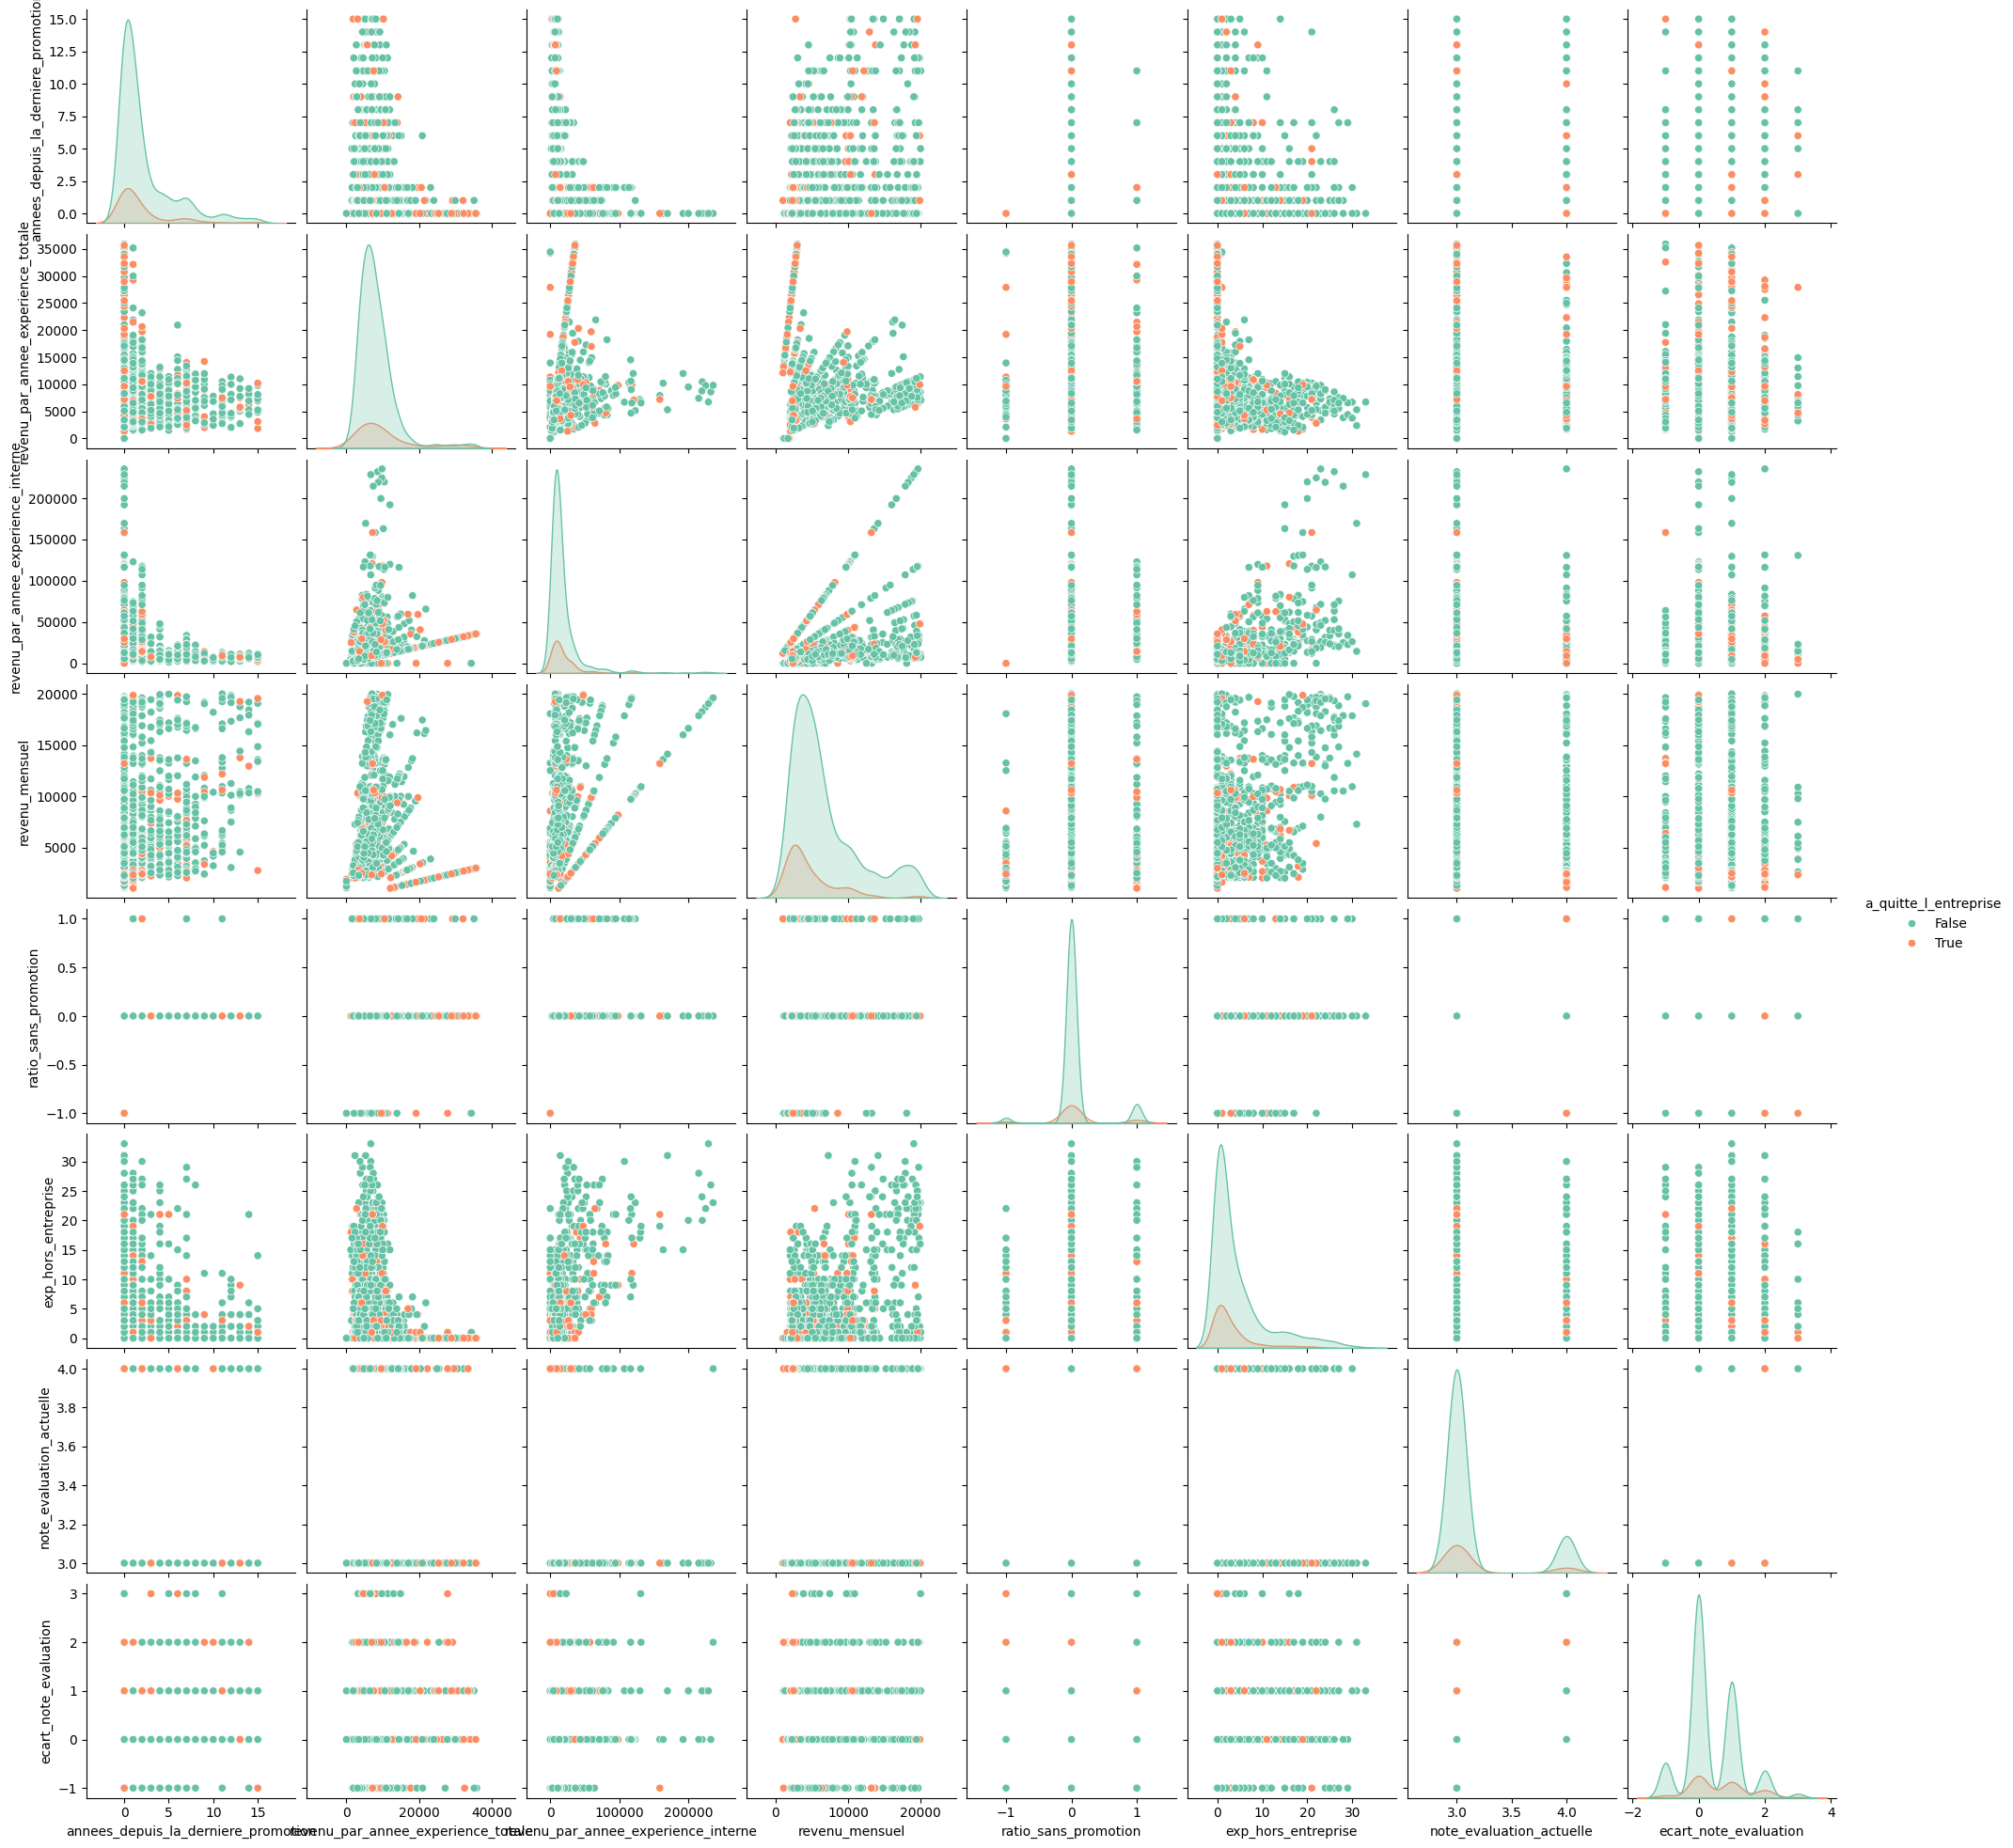

In [32]:
# Visualisation des distributions numériques selon le départ ou le maintien de l'employé - expérience en entreprise
df_num_sat_cible = df_rh_analytics_new[['a_quitte_l_entreprise', 'annees_depuis_la_derniere_promotion', 'revenu_par_annee_experience_totale', 'revenu_par_annee_experience_interne', 'revenu_mensuel',
                                        'ratio_sans_promotion', 'exp_hors_entreprise', 'note_evaluation_actuelle', 'ecart_note_evaluation']]

sns.pairplot(df_num_sat_cible, hue = 'a_quitte_l_entreprise', palette = 'Set2', diag_kind = 'kde')
plt.show()


**Corrélations numérique / cible: Corrélation pointbiserialr**

In [33]:
# Corrélations entre la cible et les variables numériques non redondantes

colonnes_quantitatives = ['nombre_experiences_precedentes', 'distance_domicile_travail', 'revenu_mensuel', 'annees_dans_l_entreprise', 'age', 'ecart_note_evaluation', 'nombre_participation_pee', 
                          'exp_hors_entreprise', 'ratio_sans_promotion', 'mobilite_promotion', 'revenu_par_annee_experience_totale', 'revenu_par_annee_experience_interne', 
                          'annees_depuis_la_derniere_promotion', 'nb_formations_suivies']

num_cols = df_rh_analytics_new[colonnes_quantitatives].columns
results = []

for col in num_cols:
    if col != 'a_quitte_l_entreprise':
        corr, p = pointbiserialr(df_rh_analytics_new['a_quitte_l_entreprise'], df_rh_analytics_new[col])
        results.append((col, corr, p))

df_pointbiserial = pd.DataFrame(results, columns=['variable', 'correlation', 'p_value'])
df_pointbiserial["p_value"] = df_pointbiserial["p_value"].apply(lambda x: f"{x:.12f}")
df_pointbiserial.sort_values(by='p_value')


,variable,correlation,p_value
9,mobilite_promotion,-0.161020,0.000000000533
2,revenu_mensuel,-0.159840,0.000000000715
4,age,-0.159205,0.000000000836
10,revenu_par_annee_experience_totale,0.147661,0.000000012868
6,nombre_participation_pee,-0.137145,0.000000130101
3,annees_dans_l_entreprise,-0.134392,0.000000231887
5,ecart_note_evaluation,0.115914,0.000008371063
7,exp_hors_entreprise,-0.082147,0.001620455080
1,distance_domicile_travail,0.077924,0.002793060080
13,nb_formations_suivies,-0.059478,0.022578499737


***Conclusion point bisérialr***

Le point bisérial mesure la force du lien entre une variable numérique et une variable binaire (ici : quitter / rester)
- les corrélations négatives signifient *plus la valeur est élevée, moins on quitte l’entreprise*
- les p-values très faibles signifient *relation statistiquement significative*.

J'ai fai une analyse des p_values car permet, statistiquement, de faire le choix des variables pertinentes et tirer les conclusions suivantes:
- Moins il y a de promomotion ou mobilité, plus l'employé risque un départ
- Plus le salaire est faible, plus l'employé part (p_value la plus basse <> *profils: 4787(partants) vs 6833(restants)*)
- Départ des plus jeunes > phénomène classique du turnover chez les jeune adultes (*profils: 34 ans en moyenne(partants) vs 38 ans(restants)*)
- Très faible engament (*profils: 0.52 participation moyenne(partants) vs 0.84(restants)*)
- Les nouveaux entrants quittent davantage (*profils: 5 ans moyenne(partants) vs 7 ans(restants)*)
- Plus la distance est grande, plus l'employé a tendance à partir (*profils: 10.6 km moyenne(partants) vs 8.9 km(restants)*)
- Moins on est formé, plus le risque de départ augmente: pas de grande différence entre les profils, mais peux constituer une cause de départ
- Les moins bien évalués est un risque de départ

**Corrélations variables qualitatives**

In [34]:
# Corrélation variables qualitatives ordinales & cible
colonnes_ordinales= ['a_quitte_l_entreprise', 'satisfaction_globale', 'note_evaluation_actuelle', 'satisfaction_employee_environnement', 'satisfaction_employee_nature_travail', 
                     'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'niveau_education']

# Matrice de corrélation de Spearman:
corr_spearman = df_rh_analytics_new[colonnes_ordinales].corr(method='spearman')
spearman_target = corr_spearman.corrwith(corr_spearman['a_quitte_l_entreprise'], method='spearman')
corr_spearman

,a_quitte_l_entreprise,satisfaction_globale,note_evaluation_actuelle,satisfaction_employee_environnement,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,niveau_education
a_quitte_l_entreprise,1.000000,-0.147716,0.002889,-0.096486,-0.102948,-0.042664,-0.051951,-0.030346
satisfaction_globale,-0.147716,1.000000,-0.032020,0.546287,0.522293,0.525606,0.329583,-0.026756
note_evaluation_actuelle,0.002889,-0.032020,1.000000,-0.029160,0.006979,-0.032989,0.006808,-0.025081
satisfaction_employee_environnement,-0.096486,0.546287,-0.029160,1.000000,-0.002993,0.005353,0.027169,-0.027625
satisfaction_employee_nature_travail,-0.102948,0.522293,0.006979,-0.002993,1.000000,-0.014679,-0.029781,-0.005175
satisfaction_employee_equipe,-0.042664,0.525606,-0.032989,0.005353,-0.014679,1.000000,0.017684,-0.013173
satisfaction_employee_equilibre_pro_perso,-0.051951,0.329583,0.006808,0.027169,-0.029781,0.017684,1.000000,0.017350
niveau_education,-0.030346,-0.026756,-0.025081,-0.027625,-0.005175,-0.013173,0.017350,1.000000


Les corrélations négatives dans le tableau de matrice confirment que la satisfaction est un levier majeur.
- **Satisfaction Globale**: La satisfaction_globale a une corrélation négative de -0.1477 avec le départ, un score très proche des facteurs économiques et d'ancienneté
- **Insatisfaction Ciblée**: L'insatisfaction de *l'environnement (-0.096) et de la nature du travail (-0.102)* sont statistiquement significatives: plus l'employé est insatisfait, plus il quitte l'entreprise; Niveau global de satisfaction faible (nature du travail, environnement, équilibre) > plus l'employé est insatisfait, plus il quitte l'entreprise

In [35]:
# Corrélations variables qualitatives nominales : Fonction qui prend en paramètres un dataframe et la variable cible, ensuite vérifie si une caractéristique (comme le poste, le statut 
# marital) est statistiquement liée à la variable cible (le départ de l'entreprise), mesure la force de ce lien et renvoie le résultat trié par la force du lien décroissant <> v_cramer

def test_chi2_et_cramer(df, target='a_quitte_l_entreprise'):

    results = []
    cols_quali = df.select_dtypes(include=['object', 'category', 'bool']).columns # Sélectionne toutes les colonnes qui contiennent des catégories ou des booléens
    
    n = len(df) # nombre total d'employés dans le jeu de données
    
    for col in cols_quali: # Pour cahque colonne dans les variables catégorielles
        if col == target: # si la variable = cible, continuer à la variable suivante
            continue

        table = pd.crosstab(df[col], df[target]) # on crée une table avec les colonnes catégorielles + cible
        chi2, p, ddl, expected = chi2_contingency(table) # on calcule l'écart et la probabilité de chaque variable dans la table
        
        l = table.shape[0]  # Nombre de lignes/catégories dans la variable
        c = table.shape[1]  # Nombre de colonnes
        min_dim = min(l - 1, c - 1)
        
        # calcul du V de Cramer (V)
        if min_dim == 0:
            cramers_v = np.nan
        else:
            cramers_v = np.sqrt(chi2 / (n * min_dim)) # On normalise l'écart (Chi2) par la taille des données (n) et la complexité de la table
        
        results.append({
            'variable': col,
            'chi2': chi2,
            'p_value': p,
            'v_cramer': cramers_v, 
            'significatif_inf5%': 'Oui' if p < 0.05 else 'Non' # Si p_value < 0.05 (5%), cela signifie que la relation est 'significative'; très peu probable que ce soit le hasard
            })
    
    # On trie le tableau pour que la 'corrélation' la plus forte (V de Cramer) apparaisse en premier.
    return pd.DataFrame(results).sort_values(by='v_cramer', ascending=False)

df_chi2 = df_rh_analytics_new.drop(columns="id_employee", axis=1)
correlation_chi2 = test_chi2_et_cramer(df_chi2, target='a_quitte_l_entreprise')
correlation_chi2

,variable,chi2,p_value,v_cramer,significatif_inf5%
6,heure_supplementaires,87.564294,8.158424e-21,0.244065,Oui
3,poste,86.190254,2.752482e-15,0.242142,Oui
1,statut_marital,46.163677,9.455511e-11,0.177211,Oui
8,categorie_employe,43.719213,1.731343e-09,0.172456,Oui
5,frequence_deplacement,24.182414,5.608614e-06,0.128260,Oui
4,domaine_etude,16.024674,6.773980e-03,0.104409,Oui
7,evolution_cat_evol,12.684418,1.760409e-03,0.092892,Oui
2,departement,10.796007,4.525607e-03,0.085698,Oui
0,genre,1.116967,2.905724e-01,0.027565,Non


***Conclusion Chi2 et V_Cramer***

Le test du Chi2 permet de vérifier si 2 variables qualitatives sont liées en calculant l'écart entre ce qu’on observe réellement et ce qu’on s’attendrait à voir si tout n’était que le fruit du hasard. Plus l’écart est grand, plus on a des raisons de penser qu’il y a une cause derrière.

Le V de cramer lui mesure la force du lien entre les variables; c'est la corrélation entre les variables qualitatives; valeur toujours comprise entre 0 et 1 elle identifie si une relation est faible/inexistante(v = 0), modérée(v entre 0.3 & 0.5) ou forte(v > 0.5)

- **Chi2** > mesure l'écart entre réalité et hazard
- **p_value** > calcule la probabilité que l'écart soit un fruit du hazard: plus il est petit, plus il est improbable que l'écart soit dû au fait du hazard
- **v_cramer** > force de la corrélation

Tous les facteurs (sauf le genre) sont statistiquement pertinents pour prédire le départ. Les leviers d'action les plus urgents seraient:
- La surcharge de Travail : Les heures supplémentaires > facteur le plus probable et le plus fort pour expliquer les départs
- Le rôle : Le poste occupé (sa nature et ses contraintes) > le type de poste a une force presque identique au facteur précédent
- Démographie/Mobilité/Type d'employé : Le statut marital, la fréquence de déplacement ainsi que le niveau d'expérience et/ou d'ancienneté de l'employé ont des forces dans le même ordre
- Par ailleurs, le genre n'a aucun lien statistiquement prouvé (p-value est trop haute, non significatif), donc le fait d'être un homme ou une femme n'augmente pas le risque de départ.


**Profils des partants vs ceux qui restent**

In [36]:
# Séparation des groupes
df_quitte = df_rh_analytics_new[df_rh_analytics_new['a_quitte_l_entreprise'] == 1]
df_reste  = df_rh_analytics_new[df_rh_analytics_new['a_quitte_l_entreprise'] == 0]

# Colonnes quantitatives pour le profil
colonnes_quantitatives = ['nombre_experiences_precedentes', 'distance_domicile_travail', 'note_evaluation_actuelle', 'revenu_mensuel', 'annees_dans_l_entreprise', 'satisfaction_globale', 'age',
                          'ecart_note_evaluation', 'satisfaction_employee_equilibre_pro_perso', 'nombre_participation_pee', 'satisfaction_employee_environnement', 'exp_hors_entreprise', 
                          'ratio_sans_promotion', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'mobilite_promotion', 'revenu_par_annee_experience_totale', 
                          'revenu_par_annee_experience_interne', 'annees_depuis_la_derniere_promotion', 'niveau_education',  'nb_formations_suivies']

colonnes_qualitatives = ['genre', 'statut_marital', 'departement', 'poste', 'domaine_etude', 'frequence_deplacement', 'heure_supplementaires', 'evolution_cat_evol', 'categorie_employe']


# Fonction pour générer le profil de chaque groupe
def profil_groupe(df, nom_groupe):
    profil = {}

    # Taille du groupe
    profil['effectif'] = len(df)
    profil['poids_dataset (%)'] = round(len(df) / len(df_rh_analytics_new) * 100, 2)

    # Age moyen
    profil['âge moyen'] = df['age'].mean()

    # Revenu
    profil['revenu annuel moyen'] = (df['revenu_mensuel']*12).mean()

    # Expérience 
    profil["expériences précédentes (moyenne)"] = df['nombre_experiences_precedentes'].mean()
    profil["années depuis dernière promotion (moyenne)"] = df['annees_depuis_la_derniere_promotion'].mean()
    profil['participation au PEE (moyenne)'] = df['nombre_participation_pee'].mean()
    profil['nombre de formations suivies (moyenne)'] = df['nb_formations_suivies'].mean()

    # Distance
    profil['distance domicile-travail moyenne'] = df['distance_domicile_travail'].mean()

    # Notes moyennes de satisfaction
    profil['evaluation actuelle (moyenne)'] = df['note_evaluation_actuelle'].mean()
    profil['ecart note actuelle vs precedente (moyenne)'] = df['ecart_note_evaluation'].mean()
    profil['satisfaction globale (moyenne)'] = df['satisfaction_globale'].mean()
    profil['environnement (moyenne)'] = df['satisfaction_employee_environnement'].mean()
    profil['nature du travail (moyenne)'] = df['satisfaction_employee_nature_travail'].mean()
    profil['equipe (moyenne)'] = df['satisfaction_employee_equipe'].mean()
    profil['equilibre pro perso (moyenne)'] = df['satisfaction_employee_equilibre_pro_perso'].mean()
    

    # Répartition des variables qualitatives
    for qual in colonnes_qualitatives:
        repartition = df[qual].value_counts(normalize=True) * 100
        for g, pct in repartition.items():
            profil[f"part {g} (%)"] = pct
    
    return pd.Series(profil, name=nom_groupe)

# 4. Construction du tableau final
profil_partants = profil_groupe(df_quitte, "Partants")
profil_restants = profil_groupe(df_reste, "Restants")

tableau_profil = pd.concat([profil_partants, profil_restants], axis=1)

tableau_profil


,Partants,Restants
effectif,237.000000,1233.000000
poids_dataset (%),16.120000,83.880000
âge moyen,33.607595,37.561233
revenu annuel moyen,57445.113924,81992.875912
expériences précédentes (moyenne),2.940928,2.645580
années depuis dernière promotion (moyenne),1.945148,2.234388
participation au PEE (moyenne),0.527426,0.845093
nombre de formations suivies (moyenne),2.624473,2.832928
distance domicile-travail moyenne,10.632911,8.915653
evaluation actuelle (moyenne),3.156118,3.153285


***Conclusion Analyse Exploratoire***

Le **point bisérial** démontre que les partants sont:
- plus jeunes
- moins payés
- moins anciens dans l'entreprise
- moins satisfaits
- moins intégrés (formation, PEE)
- plus éloignés du travail

Le **Chi2 & cramer** démontrent que les partants sont:
- dans des postes exposés au stress ou à la mobilité
- soumis à des heures supplémentaires
- dans des services plus volatils

Et les **profils moyens** confirment les précédents de façon plus intituive et visible:
- Homme, plus jeune que la moyenne, souvent célibataire
- Moins ancien dans l’entreprise
- Salaire nettement inférieur
- Charge de travail plus forte (déplacements + heures sup)
- Moins engagé dans l’entreprise (PEE)
- Niveau de satisfaction globalement plus faible
- Sur-représentation dans le commercial et certaines fonctions supports exposées

## Modélisation

#### Choix du meilleur modèle

##### Entraînement et calcul des métriques

In [37]:
# Définir le type des variables

['frequence_deplacement', 'satisfaction_employee_environnement', 'satisfaction_employee_equipe', 'note_evaluation_actuelle', 'satisfaction_employee_equilibre_pro_perso', 'satisfaction_employee_nature_travail', 
 'satisfaction_globale', 'niveau_education',]

colonnes_quantitatives = ['revenu_mensuel', 'nombre_experiences_precedentes', 'ecart_note_evaluation', 'annees_dans_l_entreprise', 'annees_depuis_la_derniere_promotion', 'nb_formations_suivies', 
                          'nombre_participation_pee', 'age', 'ratio_sans_promotion', 'distance_domicile_travail', 'revenu_par_annee_experience_totale', 'mobilite_promotion', 'exp_hors_entreprise', 
                          'revenu_par_annee_experience_interne']

colonnes_ordinales= ['frequence_deplacement', 'satisfaction_employee_environnement', 'satisfaction_employee_equipe', 'note_evaluation_actuelle', 'satisfaction_employee_equilibre_pro_perso', 
                     'satisfaction_employee_nature_travail', 'satisfaction_globale', 'niveau_education']

colonnes_qualitatives = ['genre', 'statut_marital', 'departement', 'poste', 'domaine_etude', 'heure_supplementaires', 'evolution_cat_evol', 'categorie_employe']



In [38]:
def transformation_donnees(df, colonnes_quantitatives, colonnes_qualitatives, colonnes_ordinales, cible='a_quitte_l_entreprise', id_col='id_employee', test_size=0.2, random_state=42):

    # Séparation des données
    X = df.drop(columns=[id_col, cible], axis=1)
    y = df[cible]

    # Conversion des booléens en objets pour OneHotEncoder
    for col in colonnes_qualitatives:
        if X[col].dtype == 'bool':
            X[col] = X[col].astype(object)

    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=1 - test_size, stratify=y, random_state=random_state)

    # Transformation des données - quantitatives (standardscaler), ordinales(ordinalencoder), qualitatives(onehotencoder avec l'option ignorer les valeurs nulles)
    transfo_colonnes = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), colonnes_quantitatives),
            ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=15, sparse_output=False), colonnes_qualitatives),
            ('ord', OrdinalEncoder(), colonnes_ordinales)])

    # Fit et transform sur les jeux d'entrainement, transform sur test
    X_train_final = transfo_colonnes.fit_transform(X_train)
    X_test_final = transfo_colonnes.transform(X_test)

    return X_train_final, X_test_final, y_train, y_test, transfo_colonnes

X_train_final, X_test_final, y_train, y_test, transfo = transformation_donnees(df_rh_analytics_new,colonnes_quantitatives,colonnes_qualitatives,colonnes_ordinales)


**Comparaison classique des modèles**


===== Dummy =====


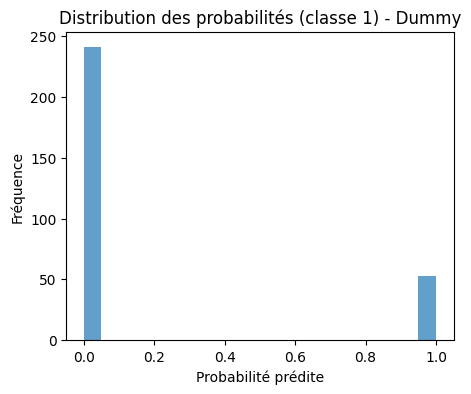

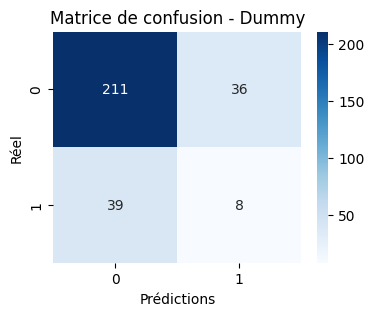

              precision    recall  f1-score   support

       False       0.84      0.85      0.85       247
        True       0.18      0.17      0.18        47

    accuracy                           0.74       294
   macro avg       0.51      0.51      0.51       294
weighted avg       0.74      0.74      0.74       294


===== LogisticRegression =====


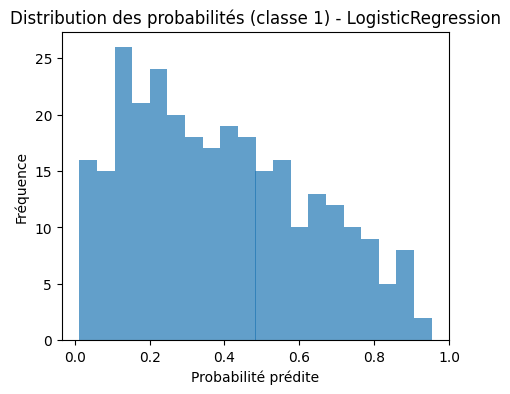

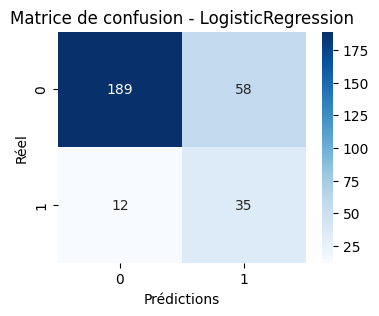

              precision    recall  f1-score   support

       False       0.94      0.77      0.84       247
        True       0.38      0.74      0.50        47

    accuracy                           0.76       294
   macro avg       0.66      0.75      0.67       294
weighted avg       0.85      0.76      0.79       294


===== RandomForest =====


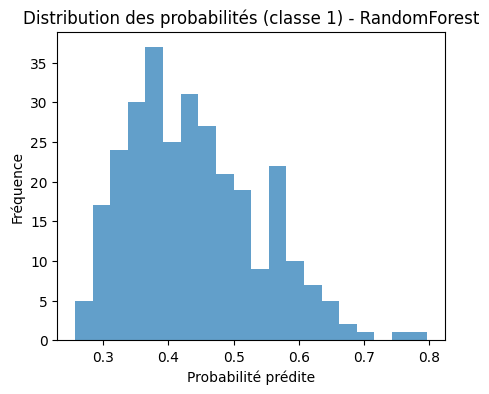

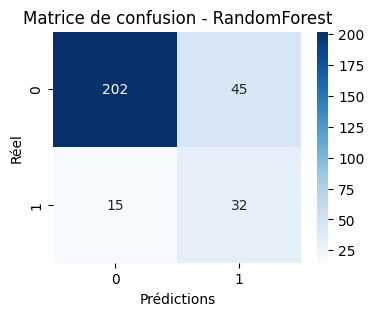

              precision    recall  f1-score   support

       False       0.93      0.82      0.87       247
        True       0.42      0.68      0.52        47

    accuracy                           0.80       294
   macro avg       0.67      0.75      0.69       294
weighted avg       0.85      0.80      0.81       294


===== XGBoost =====


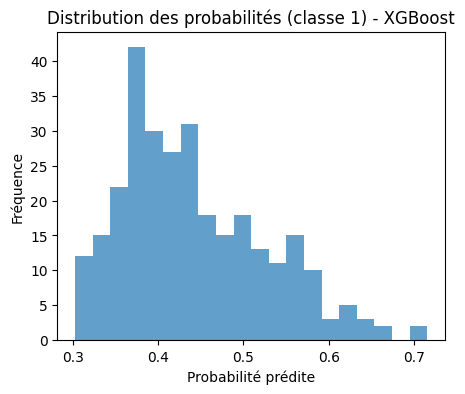

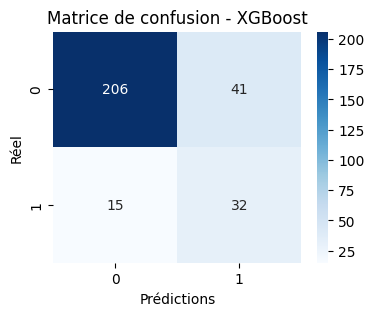

              precision    recall  f1-score   support

       False       0.93      0.83      0.88       247
        True       0.44      0.68      0.53        47

    accuracy                           0.81       294
   macro avg       0.69      0.76      0.71       294
weighted avg       0.85      0.81      0.82       294


===== SVM =====


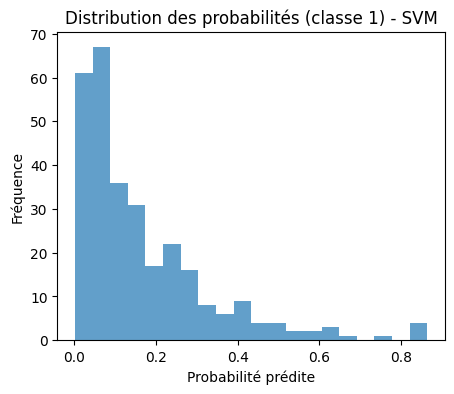

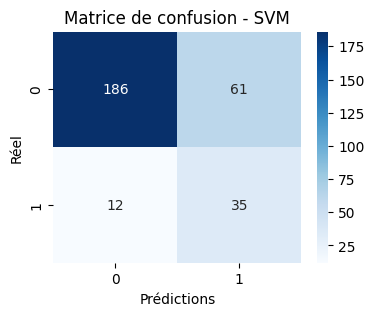

              precision    recall  f1-score   support

       False       0.94      0.75      0.84       247
        True       0.36      0.74      0.49        47

    accuracy                           0.75       294
   macro avg       0.65      0.75      0.66       294
weighted avg       0.85      0.75      0.78       294



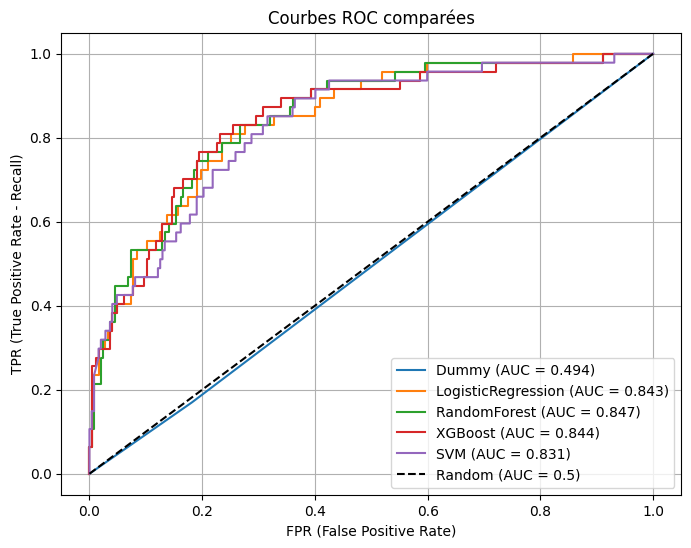

,Modèle,Precision,Rappel,Accuracy (train),Accuracy (test),F1 (train),F1 (test),ROC AUC (train),ROC AUC (test)
0,Dummy,0.181818,0.170213,0.740646,0.744898,0.177898,0.175824,0.498634,0.494013
1,LogisticRegression,0.376344,0.744681,0.771259,0.761905,0.515315,0.500000,0.854462,0.842881
2,RandomForest,0.415584,0.680851,0.836735,0.795918,0.589744,0.516129,0.856614,0.847360
3,XGBoost,0.438356,0.680851,0.853741,0.809524,0.614350,0.533333,0.871624,0.844000
4,SVM,0.364583,0.744681,0.766156,0.751701,0.508050,0.489510,0.822083,0.830907


In [39]:
# Séparation des données
X = df_rh_analytics_new.drop(columns=["id_employee", "a_quitte_l_entreprise"], axis=1)
y = df_rh_analytics_new["a_quitte_l_entreprise"]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

# Transformation des données - quantitatives (standardscaler), ordinales(ordinalencoder), qualitatives(onehotencoder avec l'option ignorer les valeurs nulles)
transfo_colonnes = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colonnes_quantitatives),
        ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=15, sparse_output=False), colonnes_qualitatives), # rechercher l'option mermettant de garder 1 seule si 2 catégories
        ('ord', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), colonnes_ordinales)])

# Définition des fonctions de traçage des probabilités et matrices de confusion
# Histogramme des probabilités
def hist_probabilities(model_name, y_proba):
    plt.figure(figsize=(5,4))
    plt.hist(y_proba, bins=20, alpha=0.7)
    plt.title(f"Distribution des probabilités (classe 1) - {model_name}")
    plt.xlabel("Probabilité prédite")
    plt.ylabel("Fréquence")
    plt.show()

# Histogramme des matrices de confusion
def hist_confusion(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matrice de confusion - {model_name}")
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
    plt.show()


# Rapport entre négatifs et positifs - pour calculer le ratio ds classes négatives et positives afin de l'utiliser dans l'hyperparamètre
neg = sum(y_train == 0) # compte le nombre de classes négatives(ceux qui restent)
pos = sum(y_train == 1) # compte le nombre de classes positives(ceux qui partent)
scale_pos_weight = neg / pos # calcul du ratio

# Définir le dictionnaire de modèles et hyperparamètres
modeles = {
    "Dummy": DummyClassifier(strategy="stratified"),
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", C=0.1),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, max_depth=3, min_samples_split=2, min_samples_leaf=2),
    "XGBoost": XGBClassifier(eval_metric="logloss", n_estimators=100, learning_rate=0.01, max_depth=3, subsample=0.4, colsample_bytree=0.4, min_child_weight=3, gamma=2,  
                             reg_lambda=3, scale_pos_weight=scale_pos_weight, random_state=42),
    "SVM": SVC(kernel = "rbf", class_weight="balanced", gamma=0.001, probability=True, random_state=42)}

comparaison_modeles = []
roc_data = {}

# Entraînement avec pipeline
# for nom, modele in modeles.items():
#     pipelines = {nom: Pipeline([
#         ("preprocessor", transfo_colonnes),
#         ("classifier", modele)])}
    

pipelines = {
    nom: Pipeline([
        ("preprocessor", transfo_colonnes),
        ("classifier", modele)
    ])
    for nom, modele in modeles.items()
}

for nom, pipe in pipelines.items():   
        pipe.fit(X_train, y_train)
        # Prédictions
        y_train_pred = pipe.predict(X_train)
        y_test_pred = pipe.predict(X_test)
        
        # Probabilités
        if hasattr(pipe.named_steps["classifier"], "predict_proba"): # si le modèle possède la méthode predict_proba() <> LR, RF, XGBOOST, Dummy mais pas SVM
            y_train_proba = pipe.predict_proba(X_train)[:, 1] # calcule la probabilité prédite pour la classe 1(True) sur le train et le test
            y_test_proba = pipe.predict_proba(X_test)[:, 1]
            
        else:  # SVM avec probability=True
            y_train_proba = pipe.decision_function(X_train) # si pas la méthode (comme le SVM), utilise cette fonction de calcul des probabilités
            y_test_proba = pipe.decision_function(X_test)
        
        fpr, tpr, _ = roc_curve(y_test, y_test_proba) # fpr(false positive rate), tpr(true positive rate) pour tous les seuils(_) possibles 
        auc = roc_auc_score(y_test, y_test_proba) # score unique entre 0.5 et 1.0 permettant de mesurer la qualité globale du modèle klk soit le seuil
        roc_data[nom] = (fpr, tpr, auc) # conservation des résultats dans un dictionnaire
    
        print(f"\n===== {nom} =====")
        hist_probabilities(nom, y_test_proba)
        hist_confusion(nom, y_test, y_test_pred)
        print(classification_report(y_test, y_test_pred))

        # Métriques classiques
        precision = precision_score(y_test, y_test_pred)
        recall = recall_score(y_test, y_test_pred)
        
        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        f1_train = f1_score(y_train, y_train_pred)
        f1_test = f1_score(y_test, y_test_pred)

        roc_auc_train = roc_auc_score(y_train, y_train_proba)
        roc_auc_test = roc_auc_score(y_test, y_test_proba)

        comparaison_modeles.append({
                'Modèle': nom,
                'Precision': precision,
                'Rappel': recall,
                'Accuracy (train)': accuracy_train,
                'Accuracy (test)': accuracy_test,
                'F1 (train)': f1_train,
                'F1 (test)': f1_test,
                'ROC AUC (train)': roc_auc_train,
                'ROC AUC (test)': roc_auc_test})
    
# Courbe ROC - Tracer dans un seul graphe toutes les courbes ROC de chaque modèle pour une meilleure comparaison
plt.figure(figsize=(8,6))
for nom, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{nom} (AUC = {auc:.3f})")
    
plt.plot([0,1], [0,1], 'k--', label="Random (AUC = 0.5)")
plt.title("Courbes ROC comparées")
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate - Recall)")
plt.legend()
plt.grid()
plt.show()

comparaison_modeles = pd.DataFrame(comparaison_modeles)
comparaison_modeles

**Comparaison des modèles en validation croisée**

In [40]:
# Validation croisée

strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultats = []
    
for nom, pipe in pipelines.items():
    f1_scores = cross_val_score(pipe, X_train, y_train,scoring="f1", cv=strat)
    auc_scores = cross_val_score(pipe, X_train, y_train,scoring="roc_auc",cv=strat)

    resultats.append({
        "Modèle": nom,
        "F1 mean": f1_scores.mean(),
        "F1 std": f1_scores.std(),
        "AUC mean": auc_scores.mean(),
        "AUC std": auc_scores.std()})

df_resultats = pd.DataFrame(resultats)
df_resultats


,Modèle,F1 mean,F1 std,AUC mean,AUC std
0,Dummy,0.179464,0.041958,0.491522,0.022980
1,LogisticRegression,0.482659,0.055676,0.812713,0.051569
2,RandomForest,0.510137,0.050448,0.794105,0.054012
3,XGBoost,0.533802,0.066817,0.799606,0.063133
4,SVM,0.483066,0.059915,0.795252,0.062231


**Test final**

In [41]:
# Test final - choix du meilleur modèle

resultats_test = []

for nom, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = pipe.decision_function(X_test)

    resultats_test.append({
        "Modèle": nom,
        "F1 test": f1_score(y_test, y_pred),
        "AUC test": roc_auc_score(y_test, y_proba)})

df_test = pd.DataFrame(resultats_test)
df_test


,Modèle,F1 test,AUC test
0,Dummy,0.125000,0.515764
1,LogisticRegression,0.500000,0.842881
2,RandomForest,0.516129,0.847360
3,XGBoost,0.533333,0.844000
4,SVM,0.489510,0.830907


##### Choix du meilleur modèle

**Interprétation et choix du meilleur modèle**

***Modèle Étalon (Dummy)***
Le modèle Dummy est le point de référence. Il montre qu’un modèle “au hasard” ne fait pas mieux que **15 % de F1 et 52 % d’AUC**. Tous les modèles d'apprentissage automatique battent largement le Dummy, ce qui valide leur pertinence.

***Analyse des autres modèles***
- **LogisticRegression**: avec un score F1 quasi identique en train (***0.51***) comme en test (***0.50***), il est un modèle simple, stable avec une tendance à détecte les faux positifs(Précision faible - 0.38); on lui note également une bonne capacité de séparation des classes (***AUC 0.84***)

- **RandomForest**: une léger overfit avec une baisse de 0.4 points (***F1 train 0.57 vs 0.53 test***), une bon équilibre entre précision (***0.43***) et rappel (***0.70***), c'est un modèle qui détecte bien les vrais positifs comparé au modèle précédent

- **XCBoost**: Bien qu'observant un écart faible du F1 score (***0.61 vs 0.57***), c'est le modèle ayant le meilleur équilibre global (***precision 0.48, rappel 0.70***) avec me meilleur score AUC (0.86); il a la meilleure performance globale

- **SVM**: modèle stable mais moins performant que XGBOOST et RandomForest

***Matrices de Confusion (Compromis Métier)***
Notre interprétation se concentre sur les **Faux Négatifs (FN)**, car ne pas identifer correctement un futur partant est plus coûteux que d'utiliser des ressources sur une faux partant (FP):
- **Capacité à Éviter les Faux Négatifs (Rappel)**: Un Rappel élevé signifie que le nombre de FN (Partants manqués) est faible. Le SVM et la LogisticRegression affichent les Rappels les plus élevés (***0.744***), minimisant le nombre de futurs partants manqués (FN=12). XGBoost et LogisticRegression présentent un Rappel faible (0.70)

- **Capacité à Éviter les Faux Positifs (Précision)**: XGBoost (0.53) est le modèle le plus précis. Il minimise le gaspillage de ressources RH sur des employés qui ne partiraient pas, le rendant plus efficient dans son ciblage

***Résultats en validation croisée***
- **Stabilité: écart-type faible**
    - RF et XGB ont les écarts-types les plus faibles → modèles stables
    - SVM instable (écart-type 0.06)

- **Performance moyenne (F1 et AUC)**
    - XGBoost a la meilleure F1 (0.53)
    - LogisticRegression et SVM sont loin derrière

Avec le résultat du test final, XGBoost généralise le mieux et confirme la validation croisée.

En combinant toutes ces analyses, **XGBOOST** est le meilleur modèle:
- Meilleure F1, meilleure AUC, faible overfit, meilleure capacité de généralisation.
- Bon équilibre précision/rappel > contrôle mieux les faux positifs et faux négatifs.
- Confirme sa supériorité en cross-validation ET en test final 


#### Recherche de meilleurs hyperparamètres

In [42]:
scoring = {
    "f1": make_scorer(f1_score, pos_label=1),
    "roc_auc": "roc_auc",
    "precision": make_scorer(precision_score, pos_label=1),
    "recall": make_scorer(recall_score, pos_label=1)}

xgb_pipe = Pipeline([
    ("preprocessor", transfo_colonnes),
    ("classifier", XGBClassifier(eval_metric = "logloss", tree_method = "hist", enable_categorical = True, scale_pos_weight = scale_pos_weight, random_state = 42))
    ])

param_dist = {
    "classifier__n_estimators": [100, 300, 500, 600],
    "classifier__learning_rate": [0.001, 0.01, 0.05, 0.1],
    "classifier__max_depth": [4, 5, 6, 7, 8, 9],
    "classifier__subsample": [0.5, 0.6, 0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 1.0],
    "classifier__min_child_weight": [1, 3, 5, 8, 10],
    "classifier__gamma": [0, 1, 2, 3, 4],
    "classifier__reg_lambda": [1, 3, 5, 7, 10],}

# Pour la recherche de meilleurs paramètres, il entraîne 200 modèles au total : 40 combinaisons d’hyperparamètres, chacune évaluée avec une validation croisée à 5 plisle meilleur 
# estimateur sera celui; puis il choisira le modèle ayant le meilleur f1_score, 
random_search = RandomizedSearchCV(estimator = xgb_pipe, param_distributions = param_dist, n_iter = 200, scoring = scoring, refit = "f1", cv = 5, verbose = 1, n_jobs = -1, random_state = 42)

random_search.fit(X_train, y_train)

best_xgb_pipe = random_search.best_estimator_
print("Meilleurs paramètres :", random_search.best_params_)
print("Meilleur score F1 CV :", random_search.best_score_)

# xgb_best_results = pd.DataFrame(random_search.cv_results_)
# xgb_best_results[["mean_test_f1", "mean_test_roc_auc", "mean_test_precision", "mean_test_recall"]]


Fitting 5 folds for each of 200 candidates, totalling 1000 fits


KeyboardInterrupt: 

In [ ]:
# Gridsearch
param_grid = {
    "classifier__n_estimators": [400, 600, 700],
    "classifier__learning_rate": [0.1, 0.2, 0.3],
    "classifier__max_depth": [3, 5, 7],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__gamma": [0, 1, 5],
    "classifier__reg_lambda": [1, 5, 10]
}

baseline_pipe = Pipeline([
    ("preprocessor", transfo_colonnes),
    ("classifier", XGBClassifier(use_label_encoder=False, eval_metric="logloss"))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=baseline_pipe, param_grid=param_grid, scoring="f1", cv=cv, n_jobs=-1)

grid_search.fit(X_train, y_train)
print("Meilleurs paramètres :", grid_search.best_params_)
print("Score F1 optimal :", grid_search.best_score_)


c:\Users\Lenovo\AppData\Local\pypoetry\Cache\virtualenvs\projet4-QK08uOpF-py3.13\Lib\site-packages\xgboost\training.py:199: UserWarning: [05:52:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Meilleurs paramètres : {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 0, 'classifier__learning_rate': 0.3, 'classifier__max_depth': 5, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 700, 'classifier__reg_lambda': 1, 'classifier__subsample': 1.0}
Score F1 optimal : 0.5296849637290814


##### Courbe Precision / Recall

Le F1-score est calculé pour chaque seuil afin d’identifier celui qui offre le meilleur compromis entre précision et rappel. La courbe PR seule ne permet pas ce choix, d’où la nécessité de calculer le F1 pour chaque seuil: f1_score = 2 * (precision * rappel) / precision + rappel

Seuil optimal : 0.19444609
F1 optimisé : 0.5471698063848345


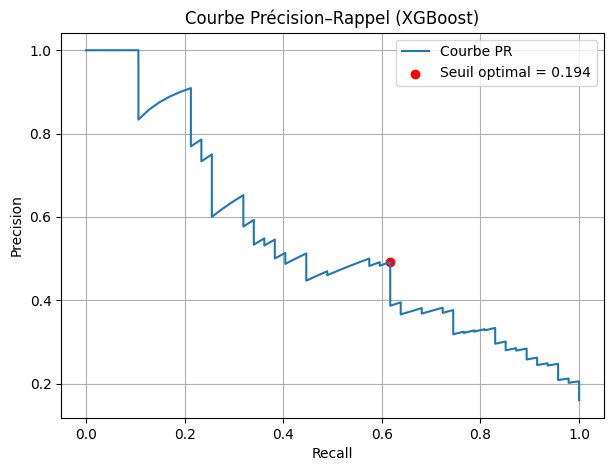

In [ ]:
#  Courbe Precision–Recall et détermination du seuil optimal qui maximise le F1
best_model = grid_search.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Seuil optimal :", best_threshold)
print("F1 optimisé :", best_f1)


# Tracé de la courbe PR
plt.figure(figsize=(7,5))
plt.plot(recall, precision, label="Courbe PR")
plt.scatter(recall[best_idx], precision[best_idx], color="red", label=f"Seuil optimal = {best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Précision–Rappel (XGBoost)")
plt.legend()
plt.grid()
plt.show()


##### Seuil optimal et matrice de confusion

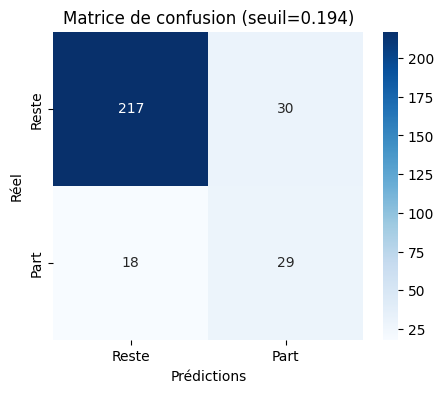

Rapport de classification (seuil=0.194)
              precision    recall  f1-score   support

       False       0.92      0.88      0.90       247
        True       0.49      0.62      0.55        47

    accuracy                           0.84       294
   macro avg       0.71      0.75      0.72       294
weighted avg       0.85      0.84      0.84       294



In [ ]:
# Application du seuil optimal
y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_proba_best >= best_threshold).astype(int)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Reste", "Part"], yticklabels=["Reste", "Part"])
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.title(f"Matrice de confusion (seuil={best_threshold:.3f})")
plt.show()

print(f"Rapport de classification (seuil={best_threshold:.3f})")
print(classification_report(y_test, y_pred_custom))


#### Importance des features

##### Importance native XGBoost

In [ ]:
best_model.fit(X_train, y_train)
best_model_imp = best_model.named_steps["classifier"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

best_native = pd.DataFrame({"Feature": feature_names, "Best_model": best_model_imp.feature_importances_}).sort_values(by="Best_model", ascending=False)
best_native.head(20)



c:\Users\Lenovo\AppData\Local\pypoetry\Cache\virtualenvs\projet4-QK08uOpF-py3.13\Lib\site-packages\xgboost\training.py:199: UserWarning: [05:52:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Feature,Best_model
38,cat__heure_supplementaires_True,0.120893
23,cat__poste_Cadre Commercial,0.072832
27,cat__poste_Représentant Commercial,0.046373
6,num__nombre_participation_pee,0.046071
37,cat__heure_supplementaires_False,0.040784
17,cat__statut_marital_Divorcé(e),0.039695
34,cat__domaine_etude_Marketing,0.038611
42,cat__categorie_employe_employe_experimente,0.033036
24,cat__poste_Consultant,0.030615
32,cat__domaine_etude_Entrepreunariat,0.029871


##### Permutation importance

In [ ]:

X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)
perm = permutation_importance(best_model_imp, X_test_transformed, y_test, scoring="f1")
perm_importance = pd.DataFrame({"feature": feature_names,"importance": perm.importances_mean}).sort_values("importance", ascending=False)

perm_importance.head(20)



,feature,importance
37,cat__heure_supplementaires_False,0.076740
9,num__distance_domicile_travail,0.067490
11,num__mobilite_promotion,0.044201
19,cat__departement_Commercial,0.041180
41,cat__evolution_cat_evol_stable,0.040907
0,num__revenu_mensuel,0.038351
46,ord__frequence_deplacement,0.036798
5,num__nb_formations_suivies,0.034497
3,num__annees_dans_l_entreprise,0.032748
52,ord__satisfaction_globale,0.032652


##### SHAP

Using 294 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 294/294 [20:38<00:00,  4.21s/it]


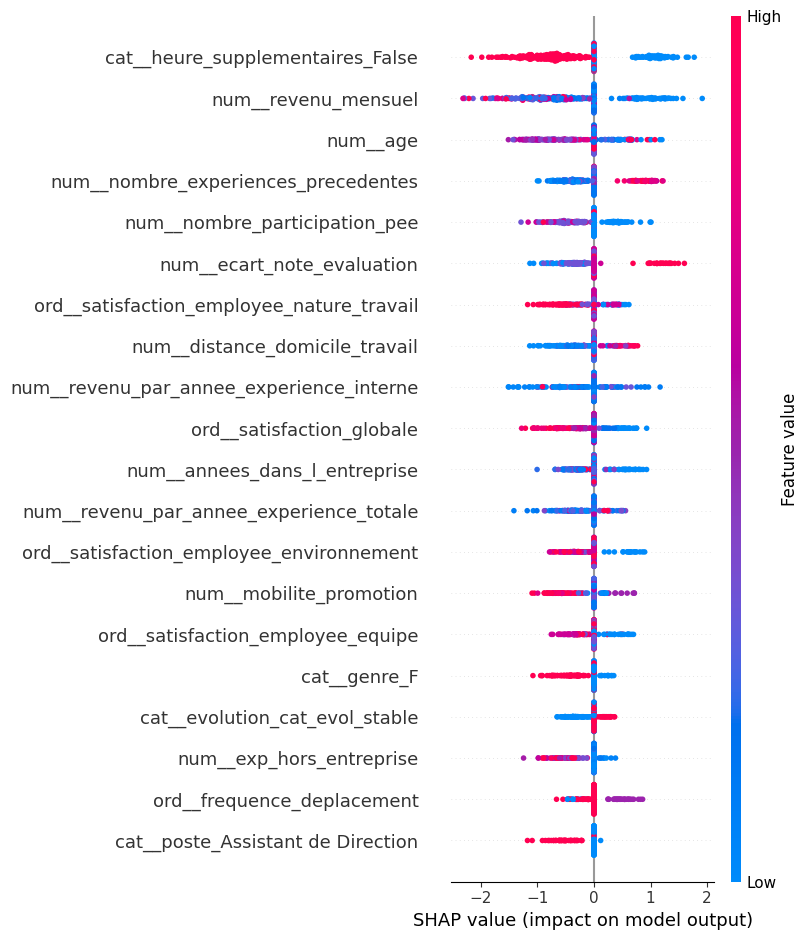

In [ ]:
# Kernel
best_xgb = best_model.named_steps["classifier"]
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)
explainer = shap.KernelExplainer(best_xgb.predict_proba, X_test_transformed, link="logit")
shap_values = explainer.shap_values(X_test_transformed)

preprocessor = best_model.named_steps["preprocessor"]
features = preprocessor.get_feature_names_out()

shap.summary_plot(shap_values[:, :, 1], X_test_transformed, feature_names=features, max_display=20)



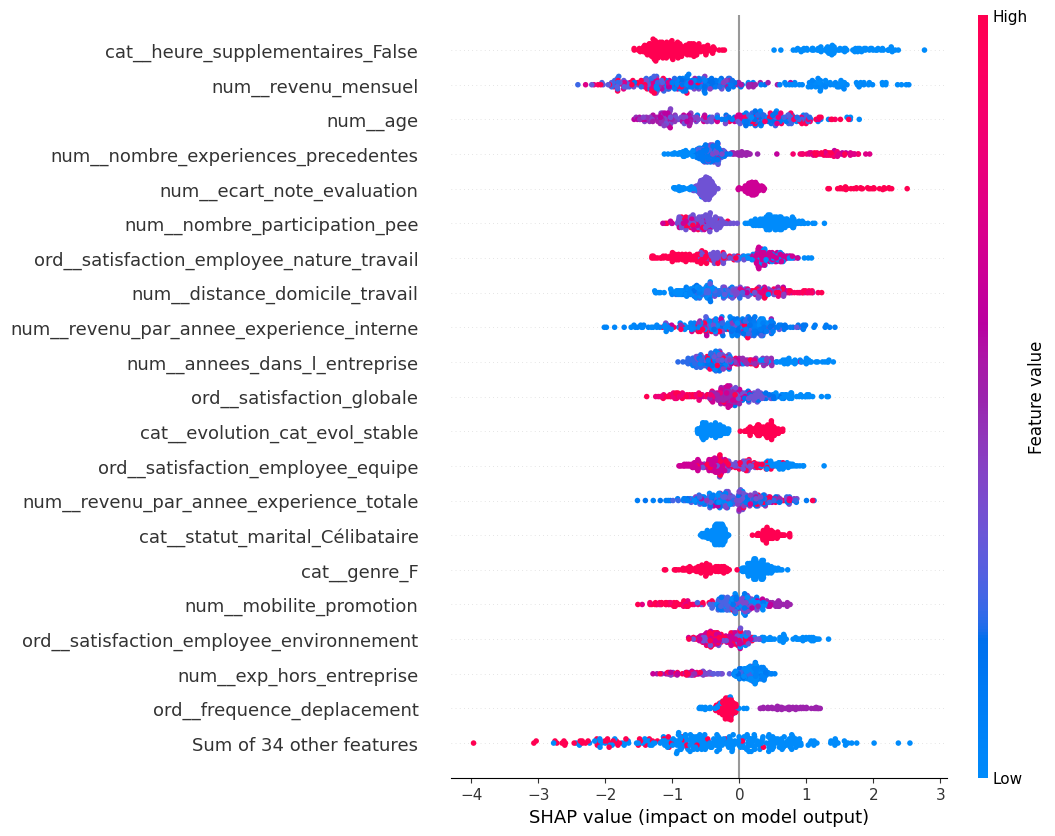

In [ ]:
booster = best_xgb.get_booster()
explainer = shap.TreeExplainer(booster)

X_test_shap = pd.DataFrame(X_test_transformed,columns=feature_names)
shap_values = explainer(X_test_shap)
shap.plots.beeswarm(shap_values, max_display=21)


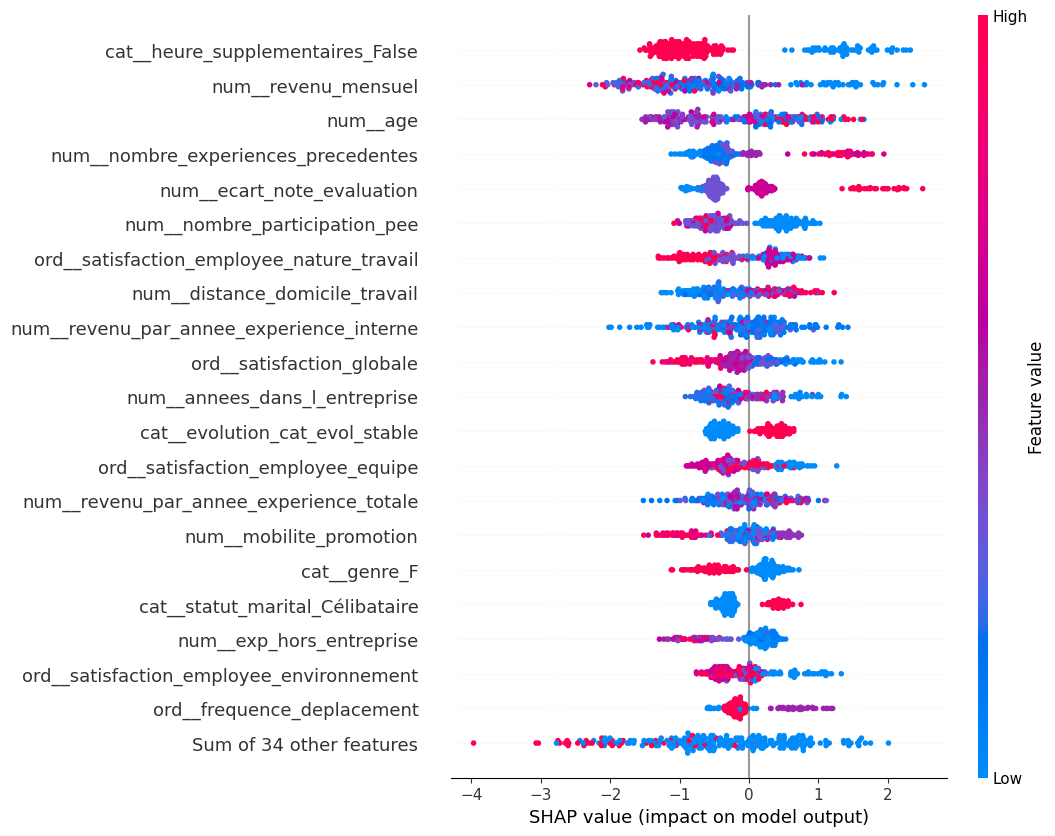

In [ ]:
mask_reste = (y_test.values == 0)
shap.plots.beeswarm(shap_values[mask_reste],max_display=21)

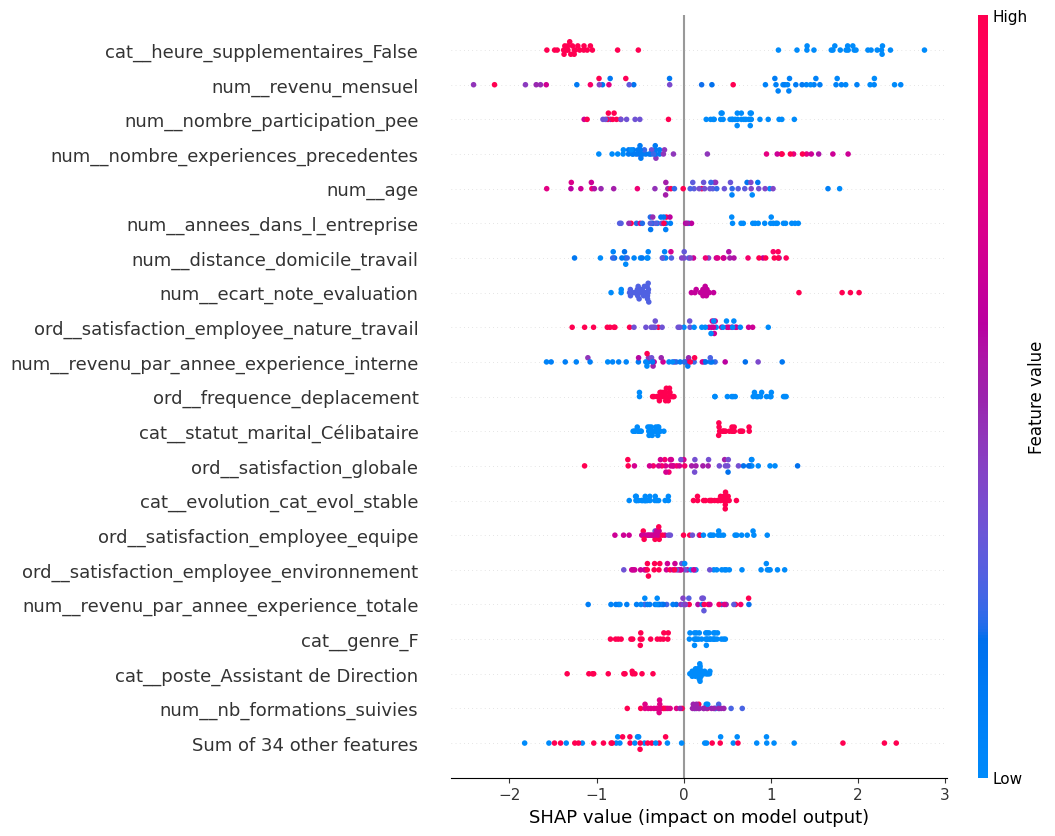

In [ ]:
mask_part = (y_test.values == 1)
shap.plots.beeswarm(shap_values[mask_part],max_display=21)

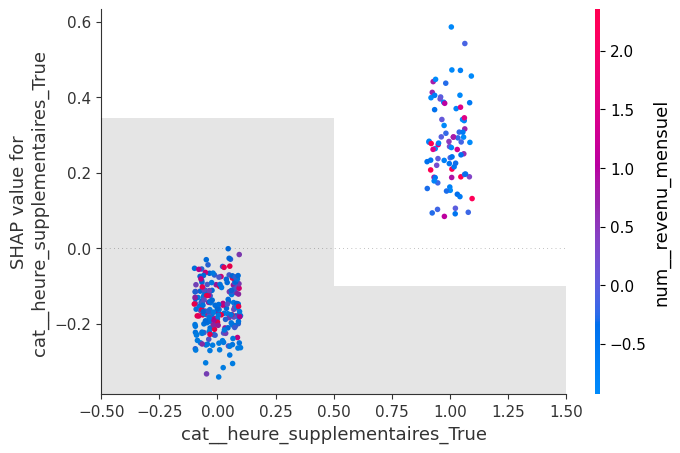

In [ ]:
idx_heursup = list(features).index('cat__heure_supplementaires_True')
idx_revenu = list(features).index('num__revenu_mensuel')
shap.plots.scatter(shap_values[:, idx_heursup],color=shap_values[:, idx_revenu])

In [ ]:
# Conversion index pandas -> position numpy
X_test_shap = X_test_shap.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Employé qui part
pos_part = y_test_reset[y_test_reset == 1].index[0]

# Employé qui reste
pos_reste = y_test_reset[y_test_reset == 0].index[0]

pos_part, pos_reste



(np.int64(4), np.int64(0))

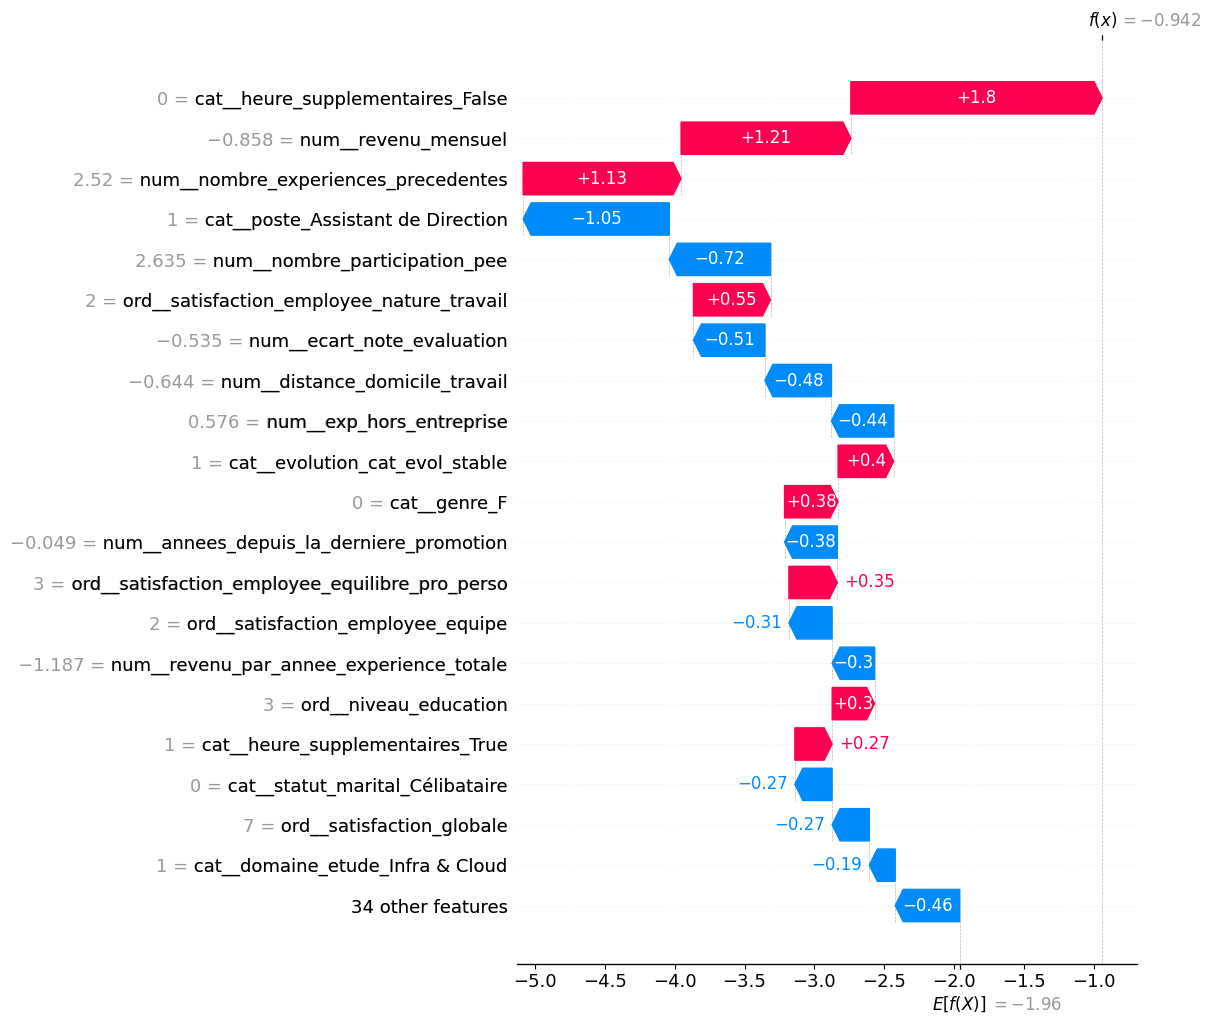

In [ ]:
i = pos_part

shap_exp_part = shap.Explanation(
    values=shap_values[i],
    base_values=explainer.expected_value,
    data=X_test_shap.iloc[i],
    feature_names=features
)

shap.plots.waterfall(shap_exp_part, max_display=21)


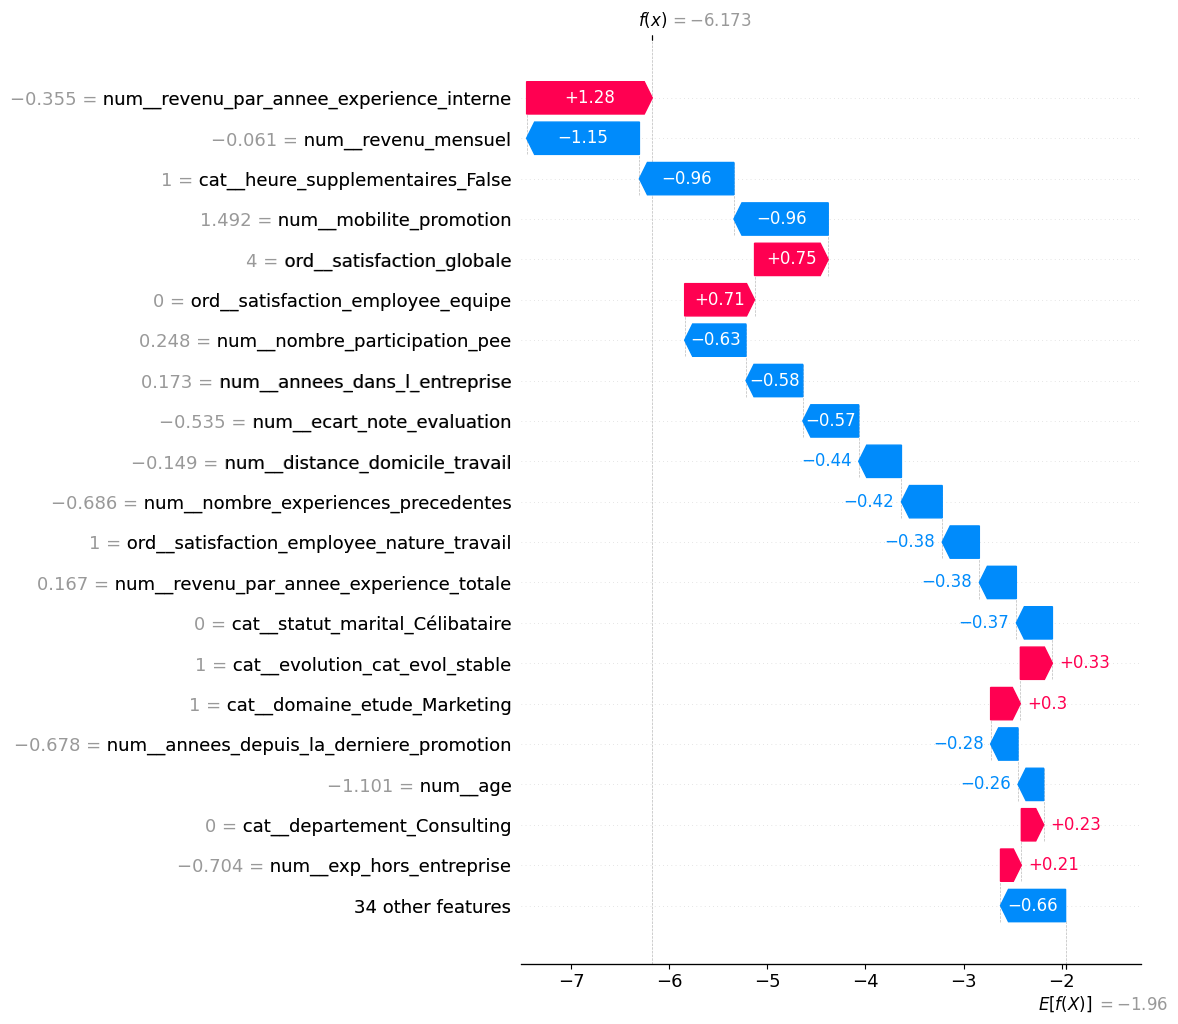

In [ ]:
i = pos_reste

shap_exp_reste = shap.Explanation(
    values=shap_values[i],
    base_values=explainer.expected_value,
    data=X_test_shap.iloc[i],
    feature_names=features
)

shap.plots.waterfall(shap_exp_reste, max_display=21)


In [ ]:
# Liste des indices des employés qui partent
indices_part = y_test_reset[y_test_reset == 1].index

# Liste des indices des employés qui restent
indices_reste = y_test_reset[y_test_reset == 0].index

# Choisir le 7e employé qui part et le 2e qui reste
pos_part1 = indices_part[7]   # attention: c'est le 8e car l'indexation commence à 0
pos_reste2 = indices_reste[2] # le 3e qui reste


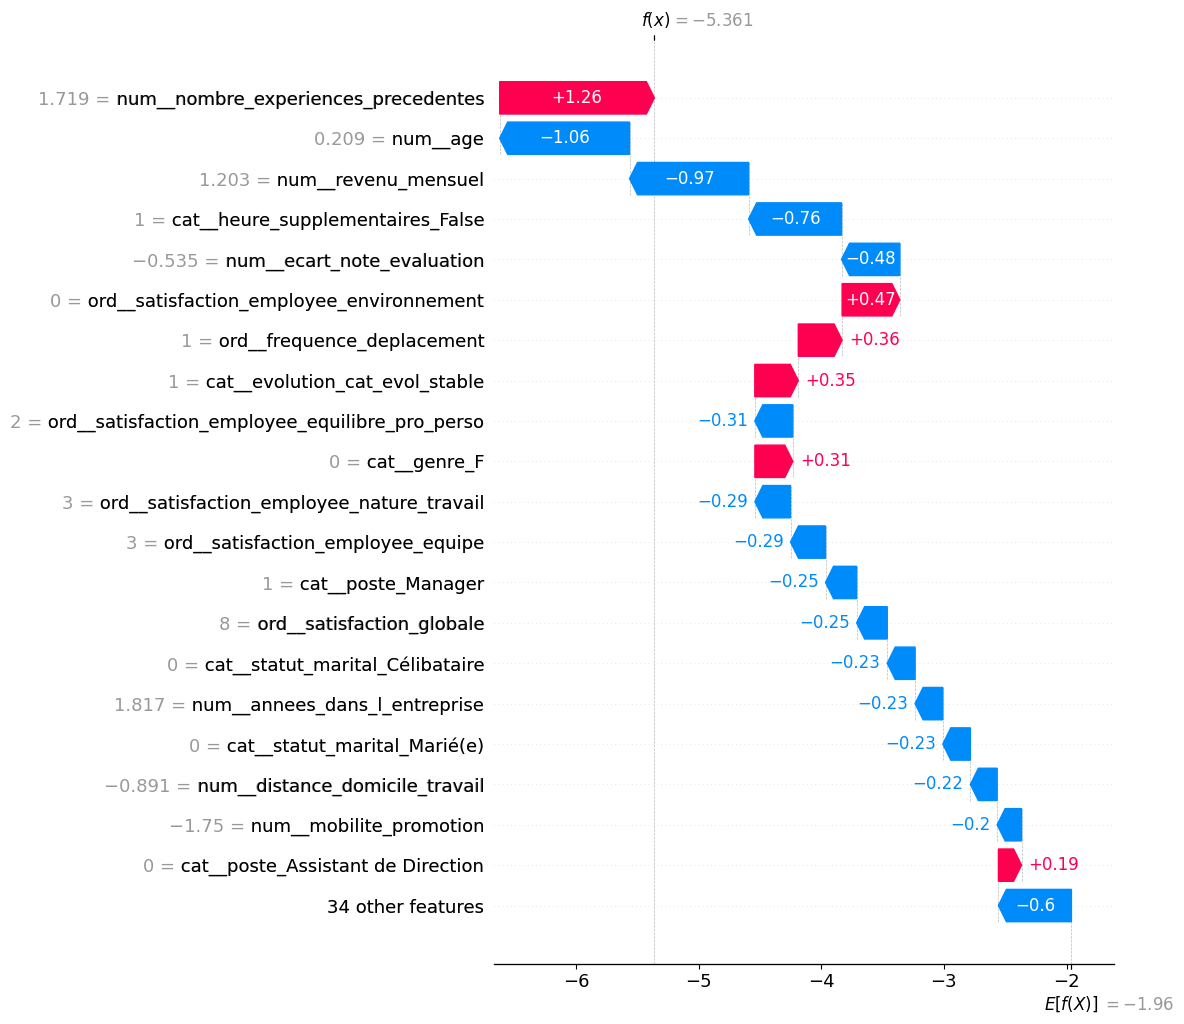

In [ ]:
p = pos_part1

shap_exp_part1 = shap.Explanation(
    values=shap_values[p],
    base_values=explainer.expected_value,
    data=X_test_shap.iloc[p],
    feature_names=features
)

shap.plots.waterfall(shap_exp_part1, max_display=21)

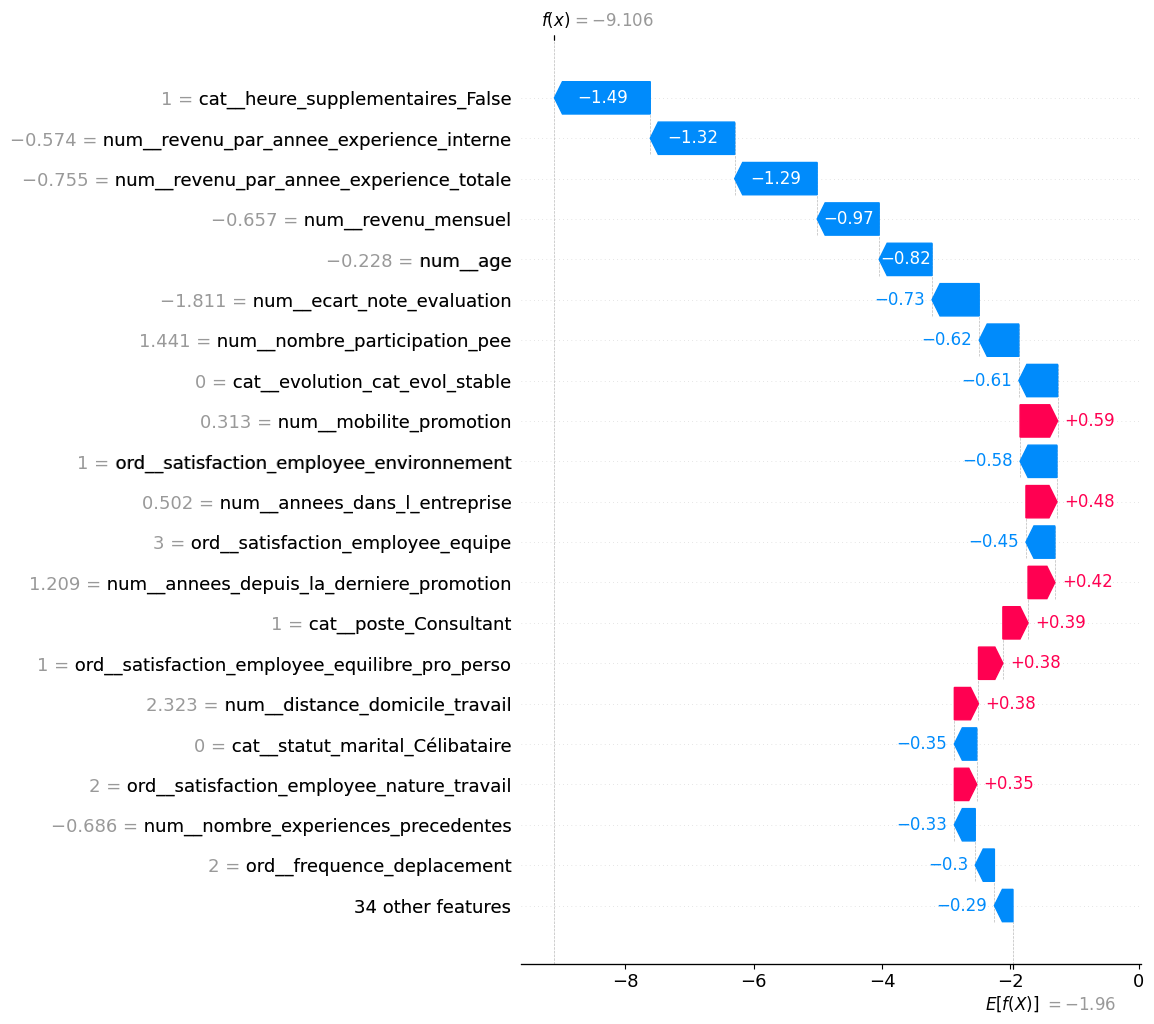

In [ ]:
r = pos_reste2

shap_exp_part2 = shap.Explanation(
    values=shap_values[r],
    base_values=explainer.expected_value,
    data=X_test_shap.iloc[r],
    feature_names=features
)

shap.plots.waterfall(shap_exp_part2, max_display=21)